# Following the money: who moves it, and who looks like they might

> AI assistance (GitHub Copilot) was used for brainstorming and code in this notebook.

This notebook picks up where `05_lda_irs_link.ipynb` left off. That notebook did the slow work of matching lobbying registrants to their IRS identities. Here we use that crosswalk to ask a harder question. We already know a handful of organizations that act as dark-money conduits. Can we find others that behave the same way but haven't been named yet?

Run the linking notebook first. It writes `high_conf_matches` and `irs_entities_addr` into `data/linking_outputs/`. The two setup cells below rebuild the DuckDB views over the S3 data and reload those tables, so this notebook runs on its own and doesn't need the other one's kernel.


In [40]:
%matplotlib inline
# DuckDB connection, S3 views, and shared matching helpers.
from pathlib import Path
import re as _re
import duckdb
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"
LINK_EXPORT_DIR = ROOT / "data" / "linking_outputs"
TRANSPARENCY_INDEX_PATH = f"{PARQUET_BASE}/transparency_index_scores/transparency_index__*.parquet"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "irs990_filing_grants",
    "irs990_filing_people",
    "irs990_filing_related_org_transactions",
    "irs990_filing_contractors",
    "irs990_filing_lobbying",
    "lobbying_bill_links",
    "lda_filings",
    "lda_lobbying_activities",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()


def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )

In [41]:
# Reload the crosswalk produced by the linking notebook and rebuild the
# EIN-to-filing bridge the network and modeling sections depend on.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "high_conf_matches.parquet").as_posix()}')
""")
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "irs_entities_addr.parquet").as_posix()}')
""")
high_conf_matches = q("SELECT * FROM high_conf_matches")

# Downstream detail tables join to matched EINs through filing_id.
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT filing.filing_id, filing.ein
FROM irs990_filings AS filing
JOIN (SELECT DISTINCT ein FROM high_conf_matches) AS matched USING (ein)
""")

print(
    f"Loaded crosswalk: {len(high_conf_matches):,} links, "
    f"{high_conf_matches['ein'].nunique():,} distinct EINs"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded crosswalk: 5,416 links, 2,910 distinct EINs


# Two ways these organizations connect

Money isn't the only thread tying these groups together, so we start with two networks over the matched cohort.

The first one follows the money. It's a directed graph where an edge means one organization granted funds to another, weighted by the dollars involved. PageRank over that graph surfaces the organizations sitting downstream of the most influential money.

The second one follows shared attention. Two organizations get linked when they lobby the same bills. We drop any bill touched by more than a hundred groups, since those crowded bills connect everyone to everyone and tell us nothing. What's left points to the central players, the brokers that bridge otherwise separate camps, and the natural issue-based communities.


In [42]:
import math
import networkx as nx
import pandas as pd
try:
    import community as community_louvain
except Exception:
    community_louvain = None

# EIN -> IRS name label map for readable node output.
ein_name = dict(high_conf_matches.drop_duplicates("ein")[["ein", "irs_name"]].values)

# ---- Funding network: grantor EIN -> grantee EIN, both inside the matched cohort ----
funding_edges = q("""
SELECT mf.ein AS src_ein, g.grantee_ein AS dst_ein,
       COUNT(*) AS n_grants, SUM(TRY_CAST(g.amount AS DOUBLE)) AS total_amount
FROM irs990_filing_grants g
JOIN matched_ein_filings mf USING (filing_id)
WHERE g.grantee_ein IN (SELECT DISTINCT ein FROM high_conf_matches)
  AND g.grantee_ein <> mf.ein
GROUP BY mf.ein, g.grantee_ein
""")

FG = nx.DiGraph()
for r in funding_edges.itertuples(index=False):
    amt = float(r.total_amount or 0.0)
    if not math.isfinite(amt) or amt < 0:
        amt = 0.0
    FG.add_edge(r.src_ein, r.dst_ein, weight=math.log1p(amt), amount=amt, n=int(r.n_grants))
# log-scaled weights keep PageRank stable across the huge dollar range.
f_pagerank = nx.pagerank(FG, weight="weight", max_iter=500)
f_dollars_in = dict(FG.in_degree(weight="amount"))
funding_top = (
    pd.DataFrame({"ein": list(f_pagerank), "pagerank": list(f_pagerank.values())})
    .assign(org=lambda d: d.ein.map(ein_name),
            dollars_received=lambda d: d.ein.map(f_dollars_in))
    .sort_values("pagerank", ascending=False).head(15)
)
print(f"Funding network: {FG.number_of_nodes():,} orgs, {FG.number_of_edges():,} edges")
display(funding_top[["org", "ein", "pagerank", "dollars_received"]])

# ---- Co-lobbying network: orgs linked by shared bills (cap mega-bills to keep it sparse) ----
org_bill = q("""
WITH client_ein AS (SELECT DISTINCT lda_key, ein FROM high_conf_matches WHERE role = 'client'),
     client_filings AS (
        SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
        FROM lda_filings WHERE json_valid(raw_json)),
     ob AS (
        SELECT DISTINCT ce.ein AS ein,
               bl.bill_type || CAST(bl.bill_number AS VARCHAR) AS bill
        FROM client_ein ce
        JOIN client_filings cf USING (lda_key)
        JOIN lobbying_bill_links bl USING (filing_uuid)
        WHERE bl.bill_number IS NOT NULL),
     bill_deg AS (SELECT bill, COUNT(*) AS n_orgs FROM ob GROUP BY bill)
SELECT ob.ein, ob.bill
FROM ob JOIN bill_deg USING (bill)
WHERE bill_deg.n_orgs BETWEEN 2 AND 100
""")

orgs = org_bill.ein.unique().tolist()
B = nx.Graph()
B.add_nodes_from(orgs, bipartite=0)
B.add_nodes_from(org_bill.bill.unique().tolist(), bipartite=1)
B.add_edges_from(map(tuple, org_bill[["ein", "bill"]].values))
CL = nx.bipartite.weighted_projected_graph(B, orgs)

c_pagerank = nx.pagerank(CL, weight="weight", max_iter=500)
c_betweenness = nx.betweenness_centrality(CL, k=min(300, CL.number_of_nodes()), seed=1)
parts = community_louvain.best_partition(CL, weight="weight") if community_louvain else {}
colobby_top = (
    pd.DataFrame({"ein": list(c_pagerank)})
    .assign(org=lambda d: d.ein.map(ein_name),
            pagerank=lambda d: d.ein.map(c_pagerank),
            betweenness=lambda d: d.ein.map(c_betweenness),
            community=lambda d: d.ein.map(parts))
    .sort_values("pagerank", ascending=False).head(15)
)
n_comm = len(set(parts.values())) if parts else 0
print(f"\nCo-lobbying network: {CL.number_of_nodes():,} orgs, {CL.number_of_edges():,} edges, {n_comm} communities")
display(colobby_top[["org", "ein", "pagerank", "betweenness", "community"]])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Funding network: 1,502 orgs, 7,368 edges


,org,ein,pagerank,dollars_received
211,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL,566001393,0.009877,4.853527e+08
1,JOHNS HOPKINS UNIVERSITY,520595110,0.007995,9.144888e+08
16,MARCH OF DIMES INC,131846366,0.007977,6.287121e+06
17,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,231352685,0.006594,4.106726e+08
28,New York University,135562308,0.006394,3.182190e+08
127,UNIVERSITY OF SOUTHERN CALIFORNIA,951642394,0.005767,4.646156e+08
56,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,135598093,0.005236,2.497808e+08
48,DUKE UNIVERSITY,560532129,0.005227,5.755696e+08
206,The Regents of the University of California,943067788,0.005143,3.309717e+09
2,Yale University,060646973,0.004958,2.773920e+08


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Co-lobbying network: 1,288 orgs, 72,923 edges, 7 communities


,org,ein,pagerank,betweenness,community
102,Chamber of Commerce of the USA,530045720,0.013224,0.064423,4
8,NATIONAL TREASURY EMPLOYEES UNION,530244795,0.007932,0.012330,3
127,Americans for the Arts Inc,521996467,0.007223,0.026815,4
214,AMERICAN CIVIL LIBERTIES UNION OF THE DISTRICT...,520749684,0.006956,0.017905,4
188,HERITAGE ACTION FOR AMERICA,272244700,0.006067,0.019396,4
39,AMERICANS FOR AMERICA Inc,844275594,0.006055,0.016322,6
132,National League for Nursing,131896510,0.005875,0.017915,6
123,HUMAN RIGHTS CAMPAIGN INC,521243457,0.005773,0.009038,3
126,AMERICAN CENTER,474245571,0.005671,0.020363,3
106,AMERICAN CHEMISTRY COUNCIL,530104410,0.005601,0.011007,0


## Zooming out to the whole money web

The cohort above is small on purpose. To see where our known dark-money groups actually sit, we rebuild the grant network for every filer in 2023 and 2024. That is hundreds of thousands of organizations and every funder-to-grantee edge we can find, each weighted by amount.

The OpenSecrets dark-money list rides along inside that web as a labeled subset. Weighted PageRank tells us how central those known groups really are, and it sets up the personalized PageRank idea we use later to find organizations that sit in similar spots.


In [43]:
# Build the FULL 2023/24 money-flow network among organizations with their own in-period filing.
import networkx as nx
import numpy as np, pandas as pd

YEARS = "(2023, 2024)"  # tax years for the money-flow network

# Repeated-digit EINs (000000000, 999999999, 111111111, ...) are redaction sentinels filers enter
# for a missing grantee, not real orgs; their inbound edges are artificial, so drop them up front.
PLACEHOLDER_EINS = tuple(str(d) * 9 for d in range(10))
_ph_sql = "(" + ", ".join(f"'{e}'" for e in PLACEHOLDER_EINS) + ")"

# Dark-money seeds loaded from the maintained S3 label file.
conn.execute(f"""CREATE OR REPLACE TEMP TABLE dark_money AS
    SELECT DISTINCT
        LPAD(CAST(filer_ein AS VARCHAR), 9, '0') AS ein,
        filer_name AS crp_name,
        latest_cycle
    FROM read_parquet('{PARQUET_BASE}/dark_money_labels.parquet')
    WHERE filer_ein IS NOT NULL""")

# Directed grant edges where both funder and grantee have a 2023/24 filing.
edges = q(f"""
WITH fy AS (
    SELECT filing_id, ein
    FROM irs990_filings
    WHERE TRY_CAST(tax_year AS INT) IN {YEARS}
)
SELECT fy.ein AS src, g.grantee_ein AS dst, SUM(TRY_CAST(g.amount AS DOUBLE)) AS amt
FROM irs990_filing_grants g JOIN fy USING (filing_id)
WHERE g.grantee_ein IS NOT NULL AND g.grantee_ein <> fy.ein
  AND g.grantee_ein IN (SELECT DISTINCT ein FROM fy)
  AND fy.ein NOT IN {_ph_sql}
  AND g.grantee_ein NOT IN {_ph_sql}
GROUP BY 1, 2
HAVING SUM(TRY_CAST(g.amount AS DOUBLE)) > 0
""")

seed_set = set(conn.execute("SELECT ein FROM dark_money").df().ein)
crp_name = conn.execute("SELECT ein, crp_name FROM dark_money").df().set_index("ein")["crp_name"].to_dict()
org_name = q("SELECT ein, current_name AS name FROM organizations").set_index("ein")["name"].to_dict()
nm = lambda e: (crp_name.get(e) or org_name.get(e) or e)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="amt", create_using=nx.DiGraph)
pr = nx.pagerank(G, weight="amt")

rank = (pd.DataFrame({"ein": list(G.nodes)})
        .assign(is_seed=lambda d: d.ein.isin(seed_set).astype(int),
                pagerank=lambda d: d.ein.map(pr),
                dollars_in=lambda d: d.ein.map(dict(G.in_degree(weight="amt"))),
                dollars_out=lambda d: d.ein.map(dict(G.out_degree(weight="amt"))),
                in_deg=lambda d: d.ein.map(dict(G.in_degree())),
                out_deg=lambda d: d.ein.map(dict(G.out_degree())))
        .sort_values("pagerank", ascending=False))
rank["name"] = rank.ein.map(nm)
rank["pr_pctile"] = rank.pagerank.rank(pct=True)

n_seed = int(rank.is_seed.sum())
print(f"FULL money web: nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}   "
      f"total grant $ {edges.amt.sum():,.0f}")
print(f"seeds present {n_seed}/{len(seed_set)}")
print(f"\nSeed centrality within the FULL web (PageRank percentile, 1.0 = most central):")
print(f"  OpenSecrets seeds : median {rank.loc[rank.is_seed==1,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==1,'pr_pctile'].mean():.3f}")
print(f"  everyone else     : median {rank.loc[rank.is_seed==0,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==0,'pr_pctile'].mean():.3f}")

print("\nTop 15 OpenSecrets seeds by PageRank within the full web:")
display(rank[rank.is_seed == 1].head(15)[
    ["name", "pagerank", "pr_pctile", "dollars_in", "dollars_out", "in_deg", "out_deg"]])
print("Top 15 orgs overall by PageRank (largest hubs in the entire money web):")
display(rank.head(15)[["name", "is_seed", "pagerank", "dollars_in", "dollars_out", "in_deg", "out_deg"]])

FULL money web: nodes 236,044   edges 863,461   total grant $ 262,707,681,195
seeds present 251/329

Seed centrality within the FULL web (PageRank percentile, 1.0 = most central):
  OpenSecrets seeds : median 0.867  mean 0.765
  everyone else     : median 0.500  mean 0.500

Top 15 OpenSecrets seeds by PageRank within the full web:


,name,pagerank,pr_pctile,dollars_in,dollars_out,in_deg,out_deg
2767,AMERICAN ACADEMY OF OPHTHALMOLOGY INC,0.000031,0.998941,23329505.0,2170295.0,11,18
6659,America Votes,0.000029,0.998818,185941769.0,155863323.0,54,94
5551,LEAGUE OF CONSERVATION VOTERS INC,0.000024,0.998445,120551953.0,54121314.0,38,76
5392,SIXTEEN THIRTY FUND,0.000024,0.998432,220079661.0,312979989.0,42,364
83083,CREDIT UNION NATIONAL ASSOCIATION INC,0.000022,0.998166,631619.0,800000.0,9,1
23,NATIONAL WILDLIFE FEDERATION,0.000020,0.997856,22470223.0,5982146.0,93,126
40455,WORKING AMERICA,0.000016,0.996895,60924596.0,0.0,17,0
22355,SIERRA CLUB,0.000015,0.996348,188937808.0,1043948.0,24,65
915,National Association of Realtors,0.000014,0.995225,157730.0,24982025.0,6,309
18188,VOTEVETS ACTION FUND INC,0.000013,0.995094,8080000.0,300000.0,16,1


Top 15 orgs overall by PageRank (largest hubs in the entire money web):


,name,is_seed,pagerank,dollars_in,dollars_out,in_deg,out_deg
1178,HABITAT FOR HUMANITY INTERNATIONAL INC,0,0.000272,4.480632e+07,1.323421e+08,195,760
19,NATL CHRISTIAN CHARITABLE FDN INC,0,0.000213,1.095042e+09,3.440956e+09,144,13535
2202,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,0.000204,1.133839e+09,7.395635e+07,461,109
1439,THE JEWISH FEDERATIONS OF NORTH AMERICA INC,0,0.000204,8.311771e+08,9.751801e+08,200,185
8298,THE ROTARY FOUNDATION OF ROTARY INTERNATIONAL,0,0.000198,1.532535e+07,4.053853e+07,184,311
866,JOHNS HOPKINS UNIVERSITY,0,0.000191,1.785949e+09,4.692834e+08,444,487
6218,President and Fellows of Harvard College,0,0.000180,6.798390e+08,3.295912e+08,374,317
684,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,0,0.000178,4.431519e+08,2.052228e+07,428,135
5407,DUKE UNIVERSITY,0,0.000178,3.856273e+09,5.334496e+06,400,98
1998,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,0,0.000174,3.684877e+08,2.921353e+08,425,398


### Where the known groups sit in the web

The medians above only summarise the story. The two charts below show the whole distribution. If the labels carried no signal, their percentiles would look flat, like everyone else's. Instead the known dark-money groups pile up toward the high end, and the cumulative curve pulls well away from the no-signal diagonal, so being a known conduit really does line up with sitting near the centre of the money web.


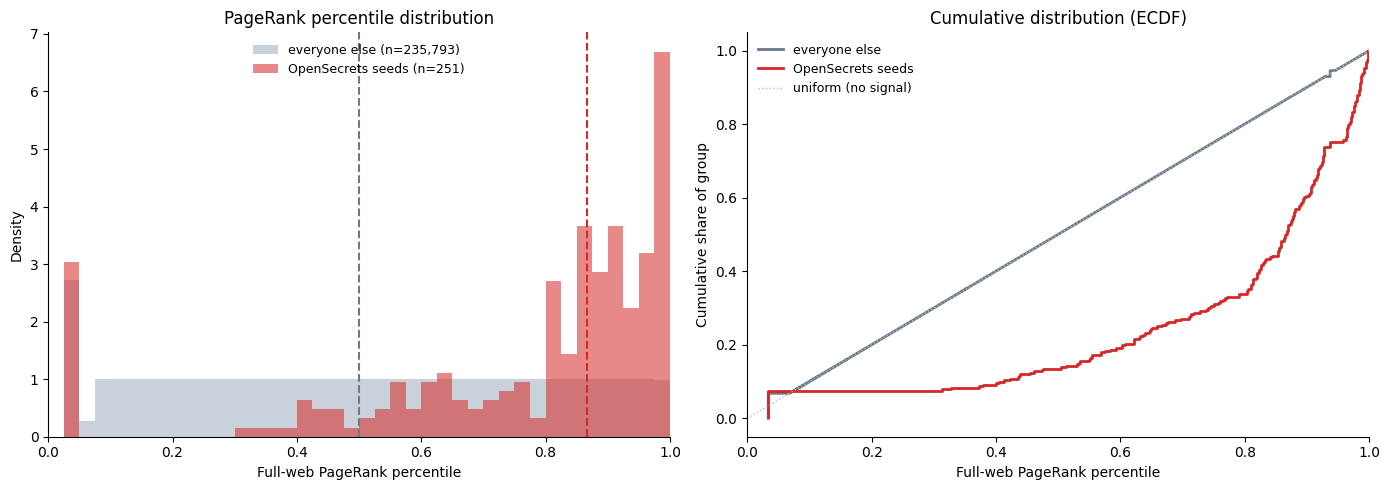

Median PageRank percentile: seeds 0.867 vs everyone else 0.500
Share landing in the top 10% of the web by PageRank: seeds 39.4% vs everyone else 10.0%


In [44]:
# Distribution of full-web PageRank percentiles: known dark-money seeds vs. everyone else.
import matplotlib.pyplot as plt
import numpy as np

seed_pct = rank.loc[rank.is_seed == 1, "pr_pctile"].dropna().to_numpy()
rest_pct = rank.loc[rank.is_seed == 0, "pr_pctile"].dropna().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 41)
axes[0].hist(rest_pct, bins=bins, density=True, color="#B8C4D0", alpha=0.75,
             label=f"everyone else (n={len(rest_pct):,})")
axes[0].hist(seed_pct, bins=bins, density=True, color="#D62828", alpha=0.55,
             label=f"OpenSecrets seeds (n={len(seed_pct):,})")
axes[0].axvline(np.median(rest_pct), color="#6B7A88", linestyle="--", linewidth=1.5)
axes[0].axvline(np.median(seed_pct), color="#D62828", linestyle="--", linewidth=1.5)
axes[0].set_title("PageRank percentile distribution")
axes[0].set_xlabel("Full-web PageRank percentile")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=9, loc="upper center")

# ECDF makes the seeds' rightward shift explicit; the diagonal is what a uniform (no-signal) set would give.
for values, color, label in [(rest_pct, "#6B7A88", "everyone else"),
                             (seed_pct, "#D62828", "OpenSecrets seeds")]:
    xs = np.sort(values)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    axes[1].step(xs, ys, where="post", color=color, linewidth=2, label=label)
axes[1].plot([0, 1], [0, 1], color="#BBBBBB", linestyle=":", linewidth=1, label="uniform (no signal)")
axes[1].set_title("Cumulative distribution (ECDF)")
axes[1].set_xlabel("Full-web PageRank percentile")
axes[1].set_ylabel("Cumulative share of group")
axes[1].legend(frameon=False, fontsize=9, loc="upper left")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.set_xlim(0, 1)

fig.tight_layout()
plt.show()

print(f"Median PageRank percentile: seeds {np.median(seed_pct):.3f} vs everyone else {np.median(rest_pct):.3f}")
print(f"Share landing in the top 10% of the web by PageRank: "
      f"seeds {(seed_pct >= 0.90).mean():.1%} vs everyone else {(rest_pct >= 0.90).mean():.1%}")


Investigating relationship between labels and latest cycles for Pagerank Percentile 

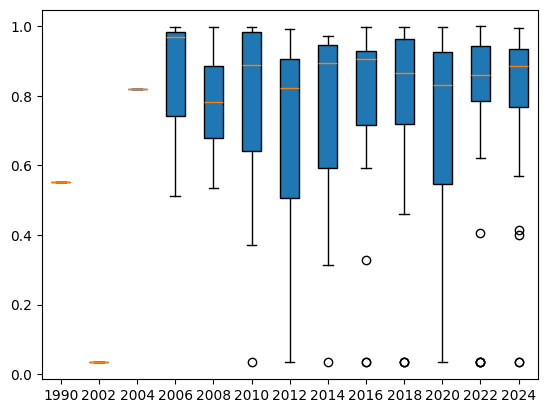

In [45]:
a = rank.loc[rank.is_seed == 1, ['ein', 'pr_pctile']].dropna()
a = a.merge(
    q("select ein, latest_cycle from dark_money"),
    on='ein',
    how='left'
)

cycles = sorted(a.latest_cycle.unique())
percentiles_by_latest_cycle = [
   [float(row[0]) for row in a.loc[:, ['pr_pctile', 'latest_cycle']].values if row[1] == cycle] for cycle in cycles
]

plt.boxplot(
    percentiles_by_latest_cycle,
    patch_artist=True,
    tick_labels=cycles
);

## Narrowing the field before we model

Our first instinct was to score all 236,000 organizations in the money web, and it backfired. The model handed high marks to hospitals, universities, and seminaries, just because large institutions move money in ways that look a little like a conduit. Scoring that far outside what the model had learned wasn't trustworthy.

So we split the difference. The structural measures (degree, dollars in and out, global PageRank) still come from the full web, because a node's position only means something in the whole graph. But the candidate pool shrinks to the known dark-money groups plus everyone within one grant hop of them. Those neighbors are the hard negatives. They are close enough to be genuinely confusable, which is what makes them a fair test.

The model weighs four kinds of evidence: where an organization sits structurally, how it behaves with its money and legal status, how political its funding neighbors are, and how close it lands to the other known seeds (computed without ever letting an org see its own label). We report cross-validated AUC next to the train-test gap, then rank the unlabeled organizations by their out-of-fold probability.

In [46]:
# Model on the seed-connected money neighborhood within the full web; full-web features + leak-free LOO-PPR proximity.
import numpy as np, pandas as pd, networkx as nx
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
# Regularized, imbalance-aware booster (reused by every modelling cell below).
# Shallow trees + low learning rate + L2 + subsample-of-features cut the old train/test
# overfitting gap (~0.10); class_weight='balanced' lifts PR-AUC on the ~6% positive pool.
def GBC():
    return HistGradientBoostingClassifier(
        loss='log_loss', learning_rate=0.05, max_iter=300,
        max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0,
        max_features=0.8, early_stopping=False,
        class_weight='balanced', random_state=42,
    )

# Candidate pool = seeds + their 1-hop grant partners within the FULL web (hard negatives).
pool = {n for n in G.nodes if n in seed_set}
for s in list(pool):
    pool |= set(G.predecessors(s)) | set(G.successors(s))
Gp = G.subgraph(pool).copy()
nodes = list(Gp.nodes)
node_ix = {n: i for i, n in enumerate(nodes)}
y = np.array([1 if n in seed_set else 0 for n in nodes], dtype=int)

# --- structural features computed over the ENTIRE web (degree, dollars, global PageRank) ---
S = pd.DataFrame({"ein": nodes})
S["in_deg"]  = S.ein.map(dict(G.in_degree()));  S["out_deg"] = S.ein.map(dict(G.out_degree()))
din  = S.ein.map(dict(G.in_degree(weight="amt"))).values
dout = S.ein.map(dict(G.out_degree(weight="amt"))).values
S["log_d_in"] = np.log1p(din); S["log_d_out"] = np.log1p(dout)
S["conduit"] = np.where((din > 0) & (dout > 0), np.minimum(din, dout) / np.maximum(np.maximum(din, dout), 1), 0.0)
S["deg"] = S.in_deg + S.out_deg

# --- behaviour features for the pool (fy scopes every source to the same YEARS window as the graph) ---
# is_527: Schedule C line 5 lists section-527 orgs a filer paid, but filers mis-enter 501(c) orgs there.
# A real 527 files Form 8871/8872, not a 990, so exclude any named EIN that appears as a 990 filer.
# Exemption subsection is kept as flags (c3/c4/c5/c6 + an explicit "other") rather than dropping non-c3456
# orgs, which would also discard orgs with a missing type -- including several known seeds.
conn.register("g_nodes", pd.DataFrame({"ein": nodes}))
behav = q(f"""
WITH e AS (SELECT DISTINCT ein FROM g_nodes),
     fy AS (SELECT filing_id, ein, exempt_organization_type
            FROM irs990_filings
            WHERE TRY_CAST(tax_year AS INT) IN {YEARS}),
     rec AS (SELECT g.grantee_ein AS ein, SUM(TRY_CAST(g.amount AS DOUBLE)) received
             FROM irs990_filing_grants g JOIN fy USING (filing_id)
             WHERE g.grantee_ein IN (SELECT ein FROM e) GROUP BY g.grantee_ein),
     go AS (SELECT fy.ein, SUM(TRY_CAST(g.amount AS DOUBLE)) granted_out
            FROM fy JOIN irs990_filing_grants g USING (filing_id)
            WHERE fy.ein IN (SELECT ein FROM e) GROUP BY fy.ein),
     lob AS (SELECT DISTINCT fy.ein FROM fy JOIN irs990_filing_lobbying l USING (filing_id)
             WHERE fy.ein IN (SELECT ein FROM e)),
     p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
              WHERE ein IN (SELECT ein FROM e)
                AND ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL)),
     eot AS (SELECT ein, mode(exempt_organization_type) AS et FROM fy
             WHERE ein IN (SELECT ein FROM e) AND exempt_organization_type IS NOT NULL GROUP BY ein)
SELECT e.ein, o.current_name AS name,
       COALESCE(rec.received,0) AS received, COALESCE(go.granted_out,0) AS granted_out,
       CASE WHEN lob.ein  IS NOT NULL THEN 1 ELSE 0 END AS has_lobbying,
       CASE WHEN p527.ein IS NOT NULL THEN 1 ELSE 0 END AS is_527,
       CASE WHEN eot.et = '501(c)(3)' THEN 1 ELSE 0 END AS eot_c3,
       CASE WHEN eot.et = '501(c)(4)' THEN 1 ELSE 0 END AS eot_c4,
       CASE WHEN eot.et = '501(c)(5)' THEN 1 ELSE 0 END AS eot_c5,
       CASE WHEN eot.et = '501(c)(6)' THEN 1 ELSE 0 END AS eot_c6,
       CASE WHEN eot.et IS NOT NULL
             AND eot.et NOT IN ('501(c)(3)', '501(c)(4)', '501(c)(5)', '501(c)(6)')
            THEN 1 ELSE 0 END AS eot_c_other
FROM e LEFT JOIN organizations o ON o.ein = e.ein
LEFT JOIN rec ON rec.ein = e.ein LEFT JOIN go ON go.ein = e.ein
LEFT JOIN lob ON lob.ein = e.ein LEFT JOIN p527 ON p527.ein = e.ein LEFT JOIN eot ON eot.ein = e.ein
""")
M = S.merge(behav, on="ein", how="left")
M["name"] = M.name.fillna(M.ein.map(lambda e: crp_name.get(e) or org_name.get(e) or e))
M["log_received"] = np.log1p(M.received); M["log_granted_out"] = np.log1p(M.granted_out)
M["velocity"]  = M.granted_out / (M.received + 1.0)
M["name_flag"] = M.name.fillna("").str.upper().str.contains(
    r"ACTION|\bFUND\b|PROJECT|ALLIANCE|NETWORK|VOTERS|FREEDOM|PROSPERITY").astype(int)

# political-neighbor feature: share of grant partners that are c4/c6/527 (IRS attributes, seeds removed -> leak-free)
# Same 527 correction: drop named 527-recipients that are actually 990 filers (mis-entered 501(c) orgs).
pol_set = set(q("""
    WITH c46 AS (SELECT DISTINCT ein FROM irs990_filings
                 WHERE exempt_organization_type IN ('501(c)(4)', '501(c)(6)','501(c)(5)')
                 And political_activity_flag = 1),
         p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
                  WHERE ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL))
    SELECT ein FROM c46 UNION SELECT ein FROM p527
""").ein) - seed_set
def _pol_feats(n):
    succ = list(G.successors(n)); pred = list(G.predecessors(n))
    po = sum(1 for x in succ if x in pol_set); pi = sum(1 for x in pred if x in pol_set)
    return (po / len(succ) if succ else 0.0, pi / len(pred) if pred else 0.0, float(po + pi))
_pf = np.array([_pol_feats(n) for n in nodes])
M["pol_out_share"], M["pol_in_share"], M["pol_deg"] = _pf[:, 0], _pf[:, 1], _pf[:, 2]
M = M.merge(rank[["ein", "pr_pctile",'pagerank']], on="ein", how="left")

STRUCTB = ["in_deg", "out_deg", "log_d_in", "log_d_out", "conduit", "deg","pagerank","pr_pctile"]
BEHAVB  = ["log_received", "log_granted_out", "velocity", "has_lobbying", "is_527",
           "name_flag", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
POL     = ["pol_out_share", "pol_in_share", "pol_deg"]
Xbase = M[STRUCTB + BEHAVB + POL].fillna(0).values

# --- single-source PPR from each seed on the pool graph, for leak-free LOO proximity ---
seeds_present = [n for n in nodes if n in seed_set]
Pmat = {}
for s in seeds_present:
    p = nx.pagerank(Gp, alpha=0.85, personalization={s: 1.0}, weight="amt", max_iter=500)
    Pmat[s] = np.array([p[n] for n in nodes])
diag = {s: Pmat[s][node_ix[s]] for s in seeds_present}

def prox(train_pos):   # proximity to OTHER seeds (leave-one-out): leak-free, symmetric for train & test
    a = np.zeros(len(nodes))
    for s in train_pos:
        a += Pmat[s]
    for s in train_pos:
        a[node_ix[s]] -= diag[s]
    return a

cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof_base, oof_prox = np.zeros(len(nodes)), np.zeros(len(nodes))
for tr, te in cv.split(Xbase, y):
    tp = [nodes[i] for i in tr if y[i] == 1]
    Xp = np.column_stack([Xbase, prox(tp)])
    oof_base[te] = GBC().fit(Xbase[tr], y[tr]).predict_proba(Xbase[te])[:, 1]
    oof_prox[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]

print(f"full web {G.number_of_nodes():,} orgs  |  candidate pool {len(nodes):,} "
      f"(seeds {int(y.sum())} + hard negatives {int((y==0).sum()):,})")
print(f"{'model':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, oof in [("structural + behaviour + political", oof_base), ("+ leave-one-out PPR proximity", oof_prox)]:
    print(f"{tag:34s} {roc_auc_score(y, oof):>11.3f} {average_precision_score(y, oof):>10.3f}")

tr, te = train_test_split(np.arange(len(nodes)), test_size=0.30, stratify=y, random_state=42)
Xp = np.column_stack([Xbase, prox([nodes[i] for i in tr if y[i] == 1])])
mdl = GBC().fit(Xp[tr], y[tr])
gtr = roc_auc_score(y[tr], mdl.predict_proba(Xp[tr])[:, 1]); gte = roc_auc_score(y[te], mdl.predict_proba(Xp[te])[:, 1])
print(f"held-out (LOO-PPR)  train {gtr:.3f}  test {gte:.3f}  gap {gtr - gte:.3f}")

M["score"] = oof_prox
M["is_seed"] = y
leads = M[M.is_seed == 0].sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):")
display(leads.head(25)[["ein", "name", "score", "pol_out_share", "pol_in_share", "received", "granted_out",
                        "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other","pagerank"]])

# --- cache feature matrix + proximity for fast offline model iteration ---
try:
    import pickle as _pkl
    _cache = ROOT / 'data' / 'netcache'; _cache.mkdir(parents=True, exist_ok=True)
    with open(_cache / 'model_inputs.pkl', 'wb') as _f:
        _pkl.dump({'Xbase': Xbase, 'y': y, 'nodes': list(nodes),
                   'Pmat': {s: Pmat[s] for s in seeds_present},
                   'seeds_present': list(seeds_present), 'node_ix': node_ix,
                   'diag': diag, 'M': M,
                   'STRUCTB': STRUCTB, 'BEHAVB': BEHAVB, 'POL': POL}, _f)
    print(f'cached model inputs -> {_cache / "model_inputs.pkl"}')
except Exception as _e:
    print('cache skipped:', _e)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

full web 236,044 orgs  |  candidate pool 3,505 (seeds 251 + hard negatives 3,254)
model                              OOF ROC-AUC OOF PR-AUC
structural + behaviour + political       0.859      0.341
+ leave-one-out PPR proximity            0.872      0.340
held-out (LOO-PPR)  train 1.000  test 0.874  gap 0.126

Top 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):


,ein,name,score,pol_out_share,pol_in_share,received,granted_out,has_lobbying,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,pagerank
0,993912822,Californians Against Job Losses and Higher Prices,0.968934,0.000000,0.000000,10000.0,0.0,1,0,0,1,0,0,0,0.000004
1,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.964460,0.000000,0.000000,0.0,10000.0,0,0,0,1,0,0,0,0.000004
2,833393572,PROGRESS ARIZONA,0.950485,0.250000,0.600000,3879568.0,475000.0,1,0,0,1,0,0,0,0.000005
3,833296530,SECURE ELECTION PROJECT INC,0.944228,0.000000,0.333333,3000000.0,0.0,1,0,0,1,0,0,0,0.000004
4,831806898,FORWARD ACTION FUND,0.934828,0.466667,0.583333,73937203.0,26608000.0,1,0,0,1,0,0,0,0.000018
5,862157002,NORTH STAR PROSPERITY,0.923459,0.000000,0.400000,4368837.0,2135000.0,1,0,0,1,0,0,0,0.000005
6,270637437,BOLD ALLIANCE INC,0.921893,0.000000,1.000000,125000.0,65750.0,1,0,0,1,0,0,0,0.000004
7,822828323,MOTHERING JUSTICE ACTION FUND,0.920849,0.000000,0.600000,1554865.0,0.0,0,0,0,1,0,0,0,0.000006
8,842852380,ORGANIZING EMPOWERMENT PROJECT INC,0.918866,0.400000,0.727273,10123624.0,2382000.0,1,0,0,1,0,0,0,0.000008
9,843646174,A BETTER WISCONSIN TOGETHER INC,0.914636,0.000000,0.500000,9157241.0,2115000.0,1,0,0,1,0,0,0,0.000010


cached model inputs -> c:\Users\kevallab\699\influence-network\data\netcache\model_inputs.pkl


### What tax status tells us

Before we look at any dollars, an organization's exemption subsection already says something about what it is for. Across the pool, comparing the share of each group that carries the flag:

- 501(c)(4): 81% of the known dark-money groups against 24% of the hard negatives, more than three times as often. These social welfare groups can spend heavily on politics without naming donors. This is the strongest single flag.
- 501(c)(6): 12% of seeds versus 16% of negatives, close enough that this flag barely separates the two. Trade associations show up on both sides, so it only helps together with lobbying and conduit behaviour.
- 501(c)(3): 6% of seeds versus 58% of negatives. A low-c3 pool is what we would expect, since public charities disclose donors and are barred from most political spending.
- 501(c)(5): 1.2% of seeds versus 1.3% of negatives, no meaningful difference.

The `is_527` flag here marks non-filer 527 orgs that appear as recipients in Schedule C but do not themselves file a 990. By that definition seeds score 0% (they are 990 filers), so this flag is more useful as a network-neighbour signal than a direct org-level one.

In [47]:
# Showcase the exemption-subsection contrast: dark-money seeds vs. non-dark-money hard negatives.
flags = ["is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
seed_rates = M.loc[y == 1, flags].mean()
neg_rates  = M.loc[y == 0, flags].mean()
profile = pd.DataFrame({
    "dark money (seed) %": (seed_rates * 100).round(1),
    "not dark money (neg) %": (neg_rates * 100).round(1),
    "lift (seed / neg)": (seed_rates / neg_rates.replace(0, np.nan)).round(2),
})
print(f"Exemption profile across {int((y==1).sum())} seeds vs {int((y==0).sum()):,} hard negatives:")
display(profile)

cols = ["ein", "name", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other", "has_lobbying", "score"]
print("\nDark-money examples (seeds carrying a c4/c6/527 political vehicle flag):")
display(M[(y == 1) & (M[["is_527", "eot_c4", "eot_c6"]].sum(axis=1) > 0)]
        .sort_values("score", ascending=False)[cols].head(10).reset_index(drop=True))

print("\nNon-dark-money examples (hard-negative c3 charities, the flag that pushes score down):")
display(M[(y == 0) & (M.eot_c3 == 1)]
        .sort_values("received", ascending=False)[cols].head(10).reset_index(drop=True))


Exemption profile across 251 seeds vs 3,254 hard negatives:


,dark money (seed) %,not dark money (neg) %,lift (seed / neg)
is_527,0.0,0.0,NaN
eot_c3,5.6,57.9,0.10
eot_c4,80.9,24.1,3.36
eot_c5,1.2,1.3,0.95
eot_c6,11.6,15.8,0.73
eot_c_other,0.8,0.5,1.53



Dark-money examples (seeds carrying a c4/c6/527 political vehicle flag):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,993614737,Independent Veterans of America Action,0,0,1,0,0,0,1,0.983042
1,452600535,AMERICAN COMMITMENT,0,0,1,0,0,0,1,0.978307
2,541564919,THE 60 PLUS ASSOCIATION INC,0,0,1,0,0,0,0,0.978137
3,992011538,WISCONSIN PRINCIPLES INC,0,0,1,0,0,0,1,0.967415
4,262731617,AMERICAN ENERGY ALLIANCE,0,0,1,0,0,0,0,0.962583
5,521733698,LEAGUE OF CONSERVATION VOTERS INC,0,0,1,0,0,0,1,0.961569
6,201597444,TRUMAN NATIONAL SECURITY PROJECT,0,0,1,0,0,0,0,0.961534
7,260596684,EDUCATION REFORM NOW ADVOCACY INC,0,0,1,0,0,0,1,0.950501
8,822007387,NATIONAL SECURITY ACTION,0,0,1,0,0,0,1,0.950137
9,030554750,CENTER FOR VOTER INFORMATION,0,0,1,0,0,0,1,0.944804



Non-dark-money examples (hard-negative c3 charities, the flag that pushes score down):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,416011702,MAYO CLINIC,0,1,0,0,0,0,1,0.005590
1,560532129,DUKE UNIVERSITY,0,1,0,0,0,0,1,0.004457
2,237825575,NATIONAL PHILANTHROPIC TRUST,0,1,0,0,0,0,1,0.003486
3,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,0,1,0,0,0,0,1,0.013659
4,135562308,New York University,0,1,0,0,0,0,1,0.036554
5,520595110,JOHNS HOPKINS UNIVERSITY,0,1,0,0,0,0,1,0.005018
6,311640316,DONOR ADVISED CHARITABLE GIVING INC,0,1,0,0,0,0,1,0.007110
7,941156365,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,1,0,0,0,0,1,0.002100
8,581493949,NATL CHRISTIAN CHARITABLE FDN INC,0,1,0,0,0,0,0,0.000772
9,205205488,Silicon Valley Community Foundation,0,1,0,0,0,0,1,0.013223


## From model score to a shortlist

A high score means one thing: this organization moves money like the ones we already know. It does not mean the organization is political. Left alone, the ranking pushes up big institutions that just have unusual finances.

So before a name goes on a shortlist, we ask for a second reason to keep it. We count five signs of political relevance: reported lobbying, 527 status, (c)(4) status, (c)(6) status, and having at least a quarter of its grant partners be political organizations. If we require two of the five, most of the institutional noise drops out and we keep almost all of the known labels.

The table tries one, two, and three signals so you can see the trade-off between keeping real labels and dropping hard negatives. Two worked best. This is a filter applied after scoring, so it does not change the model or the scores.


Threshold: 0.495
                 pred not_dark   pred dark
  actual not_dark        2,951         303
  actual dark              115         136
  precision 0.310 | recall 0.542 | f1 0.394


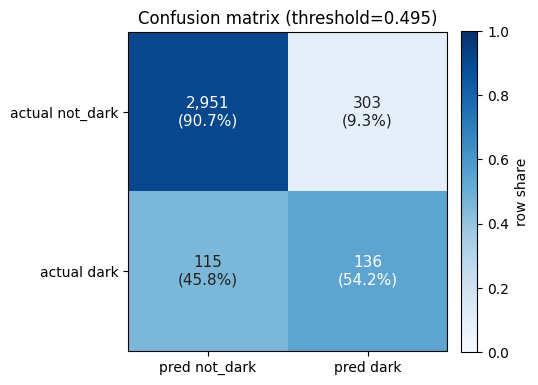

In [48]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

CLASSIFICATION_THRESHOLD = 0.495
pred = oof_prox >= CLASSIFICATION_THRESHOLD

tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
print(f"Threshold: {CLASSIFICATION_THRESHOLD}")
print(f"                 pred not_dark   pred dark")
print(f"  actual not_dark {tn:12,d}  {fp:10,d}")
print(f"  actual dark     {fn:12,d}  {tp:10,d}")
print(f"  precision {precision_score(y, pred):.3f} | recall {recall_score(y, pred):.3f} | f1 {f1_score(y, pred):.3f}")

cm = np.array([[tn, fp], [fn, tp]])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
labels = ["not_dark", "dark"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"pred {l}" for l in labels])
ax.set_yticks([0, 1]); ax.set_yticklabels([f"actual {l}" for l in labels])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})",
                ha="center", va="center", fontsize=11,
                color="white" if cm_norm[i,j] > 0.5 else "#222")
ax.set_title(f"Confusion matrix (threshold={CLASSIFICATION_THRESHOLD})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row share")
plt.tight_layout()
plt.show()


Investigate Model Scores against the latest cycle

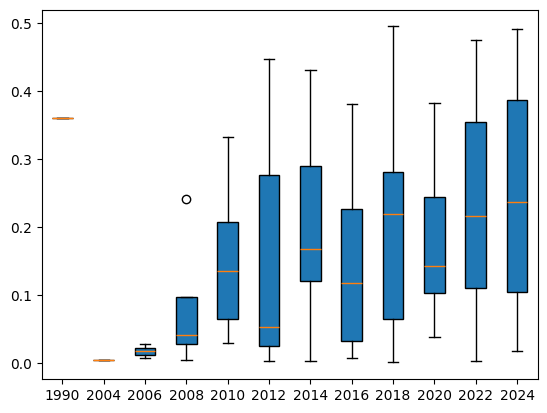

In [49]:
# Working backwards from 'pred' --> 'oof_prox' --> M["score"] --> M
y, pred, oof_prox, M["score"]
false_negatives = M.loc[(M.score.lt(CLASSIFICATION_THRESHOLD)) & (M.is_seed == 1), ['ein', 'score']]
false_negatives = false_negatives.merge(
    q("select ein, latest_cycle from dark_money"),
    on='ein',
    how='left'
)

cycles = sorted(false_negatives.latest_cycle.unique())
scoress_by_latest_cycle = [
   [float(row[0]) for row in false_negatives.loc[:, ['score', 'latest_cycle']].values if row[1] == cycle] for cycle in cycles
]

plt.boxplot(
    scoress_by_latest_cycle,
    patch_artist=True,
    tick_labels=cycles
);

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

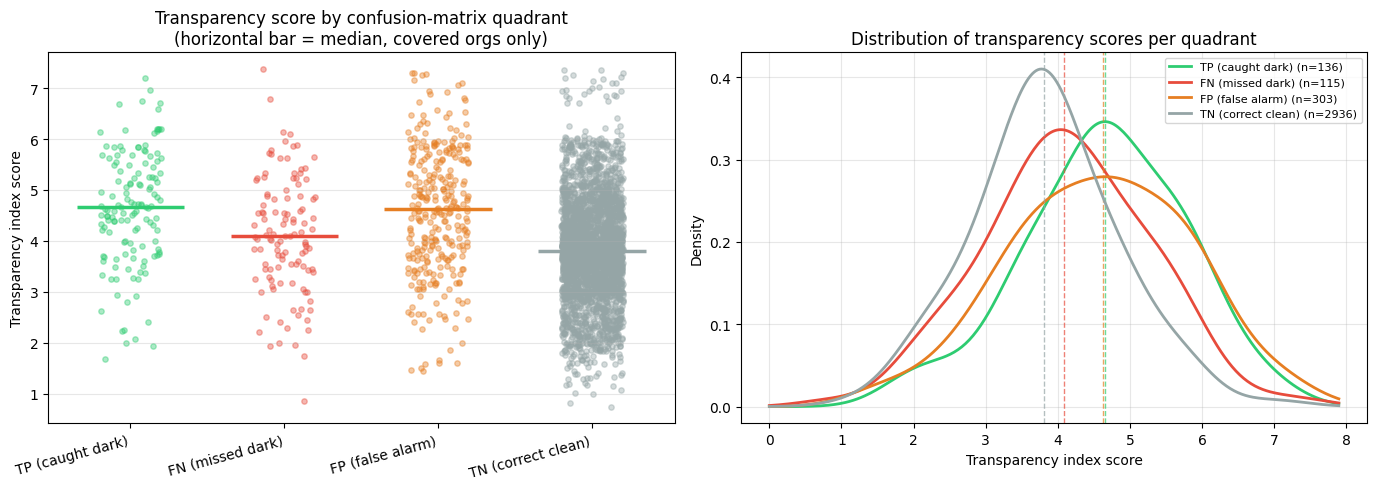


Transparency coverage and score by quadrant:


,total,with_ti,coverage,median_ti,mean_ti
quadrant,,,,,
TP (caught dark),136,136,100.0%,4.658,4.639
FN (missed dark),115,115,100.0%,4.086,4.107
FP (false alarm),303,303,100.0%,4.629,4.570
TN (correct clean),2951,2936,99.5%,3.801,3.820


In [50]:
# Load transparency index data (required before quadrant analysis).
conn.execute(f"""
CREATE OR REPLACE VIEW transparency_index AS
SELECT *
FROM read_parquet(
    '{TRANSPARENCY_INDEX_PATH}',
    union_by_name=true
)
""")

transparency = q(f"""
WITH ranked AS (
    SELECT
        ein,
        tax_year,
        normalized_index_score,
        observed_components,
        complete,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY tax_year DESC, filing_id DESC
        ) AS recency
    FROM transparency_index
    WHERE tax_year IN {YEARS}
)
SELECT * EXCLUDE recency
FROM ranked
WHERE recency = 1
""")
_valid_years = {int(yr.strip()) for yr in YEARS.strip("()").split(",")}
transparency = transparency[transparency["tax_year"].isin(_valid_years)].reset_index(drop=True)

# --- Transparency index position for each confusion-matrix quadrant ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cm_labels = {
    "TP (caught dark)": (y == 1) & pred,
    "FN (missed dark)": (y == 1) & ~pred,
    "FP (false alarm)": (y == 0) & pred,
    "TN (correct clean)": (y == 0) & ~pred,
}
colors = {"TP (caught dark)": "#2ecc71", "FN (missed dark)": "#e74c3c",
          "FP (false alarm)": "#e67e22", "TN (correct clean)": "#95a5a6"}

# Join transparency scores onto M
ti = transparency[["ein", "normalized_index_score"]].drop_duplicates("ein")
Mti = M[["ein"]].copy()
Mti["ti_score"] = Mti.ein.map(ti.set_index("ein").normalized_index_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: strip / swarm plot of transparency scores per quadrant (covered orgs only)
ax = axes[0]
covered_groups = {}
for i, (label, mask) in enumerate(cm_labels.items()):
    scores = Mti.loc[mask, "ti_score"].dropna()
    covered_groups[label] = scores
    jitter = np.random.default_rng(i).uniform(-0.2, 0.2, len(scores))
    ax.scatter(np.full(len(scores), i) + jitter, scores,
               alpha=0.4, s=15, color=colors[label], label=label)
    ax.hlines(scores.median(), i - 0.35, i + 0.35,
              color=colors[label], linewidth=2.5)
ax.set_xticks(range(len(cm_labels)))
ax.set_xticklabels(list(cm_labels.keys()), rotation=15, ha="right")
ax.set_ylabel("Transparency index score")
ax.set_title("Transparency score by confusion-matrix quadrant\n(horizontal bar = median, covered orgs only)")
ax.grid(axis="y", alpha=0.3)

# Right: overlapping KDE / histogram of transparency percentile per quadrant
ax2 = axes[1]
from scipy.stats import gaussian_kde
all_scores = ti["normalized_index_score"].dropna()
xgrid = np.linspace(all_scores.min(), all_scores.max(), 300)
for label, scores in covered_groups.items():
    if len(scores) < 5:
        continue
    kde = gaussian_kde(scores, bw_method=0.4)
    ax2.plot(xgrid, kde(xgrid), color=colors[label], linewidth=2, label=f"{label} (n={len(scores)})")
    ax2.axvline(scores.median(), color=colors[label], linewidth=1, linestyle="--", alpha=0.7)
ax2.set_xlabel("Transparency index score")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of transparency scores per quadrant")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\nTransparency coverage and score by quadrant:")
rows = []
for label, mask in cm_labels.items():
    scores = Mti.loc[mask, "ti_score"].dropna()
    total = int(mask.sum())
    rows.append({"quadrant": label, "total": total,
                 "with_ti": len(scores), "coverage": len(scores)/total if total else 0,
                 "median_ti": scores.median() if len(scores) else float("nan"),
                 "mean_ti": scores.mean() if len(scores) else float("nan")})
import pandas as pd
summary = pd.DataFrame(rows).set_index("quadrant")
display(summary.style.format(
    {"coverage": "{:.1%}", "median_ti": "{:.3f}", "mean_ti": "{:.3f}"}
).set_caption("Transparency index coverage and scores per confusion-matrix quadrant"))


In [51]:
# --- False Negatives: known dark-money seeds the model missed ---
fn_mask = (y == 1) & ~pred

fn_cols = [
    "ein", "name", "score", "pr_pctile",
    "conduit", "velocity",
    "in_deg", "out_deg",
    "pol_out_share", "pol_in_share",
    "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6","pagerank"
]
fn_df = M.loc[fn_mask, fn_cols].sort_values("score", ascending=False).reset_index(drop=True)

print(f"False negatives: {fn_mask.sum()} known seeds the model scored below {CLASSIFICATION_THRESHOLD}")
print(f"Score range among FNs: {fn_df.score.min():.3f} - {fn_df.score.max():.3f} "
      f"(median {fn_df.score.median():.3f})")
print()

# Why does the model miss them? Check structural signals.
tp_mask = (y == 1) & pred
print("Signal comparison: FN seeds vs TP seeds (medians)")
compare_cols = ["score", "pr_pctile", "conduit", "velocity", "in_deg", "out_deg",
                "pol_out_share", "pol_in_share", "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6","pagerank"]
comparison = (
    M.loc[fn_mask, compare_cols].median()
    .rename("FN (missed)")
    .to_frame()
    .join(M.loc[tp_mask, compare_cols].median().rename("TP (caught)"))
)
display(comparison.style.format("{:.3f}").set_caption("Median feature values: missed vs caught seeds"))

print("\nTop 15 missed seeds by score:")
display(fn_df.head(15).style.format(
    {c: "{:.3f}" for c in ["score", "conduit", "velocity",
                           "pol_out_share", "pol_in_share"]} |
    {"pr_pctile": "{:.1%}"}
).set_caption(f"False negatives @ threshold={CLASSIFICATION_THRESHOLD} (top 15 by score)"))


False negatives: 115 known seeds the model scored below 0.495
Score range among FNs: 0.001 - 0.495 (median 0.182)

Signal comparison: FN seeds vs TP seeds (medians)


,FN (missed),TP (caught)
score,0.182,0.746
pr_pctile,0.863,0.869
conduit,0.005,0.000
velocity,0.133,0.095
in_deg,4.000,4.500
out_deg,1.000,1.000
pol_out_share,0.000,0.000
pol_in_share,0.286,0.500
has_lobbying,1.000,1.000
is_527,0.000,0.000



Top 15 missed seeds by score:


,ein,name,score,pr_pctile,conduit,velocity,in_deg,out_deg,pol_out_share,pol_in_share,has_lobbying,is_527,eot_c3,eot_c4,eot_c5,eot_c6,pagerank
0,272244700,HERITAGE ACTION FOR AMERICA,0.495,97.2%,0.022,0.293,7,1,1.000,0.286,1,0,0,1,0,0,0.000008
1,530104410,AMERICAN CHEMISTRY COUNCIL,0.490,96.5%,0.194,5.636,2,21,0.095,0.000,1,0,0,0,0,1,0.000007
2,471746234,We Vote We Win,0.475,83.3%,0.000,0.000,7,0,0.000,0.571,0,0,0,1,0,0,0.000004
3,852851625,WE ACT 4 CHANGE INC,0.463,63.0%,0.000,0.000,2,0,0.000,0.500,1,0,0,1,0,0,0.000004
4,201734070,THIRD WAY,0.462,99.3%,0.030,0.049,14,6,0.167,0.571,1,0,0,1,0,0,0.000011
5,881133984,MI PODER,0.458,87.5%,0.000,0.000,6,0,0.000,0.333,0,0,0,1,0,0,0.000005
6,813625061,Black Voters Matter Fund Inc,0.454,98.9%,0.071,0.084,17,6,0.833,0.588,1,0,0,1,0,0,0.000010
7,824259151,Community Water Center Action Fund,0.448,91.2%,0.000,0.029,2,0,0.000,0.000,1,0,0,1,0,0,0.000006
8,205355252,ENVIRONMENT AMERICA INC,0.447,92.5%,0.061,1.488,7,4,0.250,0.429,1,0,0,1,0,0,0.000007
9,260573960,Fuse Washington,0.447,82.6%,0.274,4.771,6,13,0.462,0.667,1,0,0,1,0,0,0.000004


## Checking against the transparency index

There's an outside yardstick worth pulling in here: the transparency index, which scores how much each organization actually discloses. We match it in by EIN, keep the most recent filing for each org, and line the known dark-money groups up against everyone else in the pool.

The gap is real but modest. The known groups sit at a median transparency score of 4.4; the rest of the pool sits at 3.8. We also tried folding the index straight into the model as another feature, and it changed nothing worth reporting -- ROC-AUC slipped from 0.866 to 0.865 and PR-AUC from 0.362 to 0.357, which is just noise. So we keep it out of the model and use it the way it reads best: as a second opinion. Of the 309 organizations the model flags without a label, most land on the opaque side, which is at least reassuring -- it isn't lighting up transparent institutions at random.

A low score is a reason to look closer, not a verdict. We treat it as one more piece of evidence and leave it at that.

In [52]:
# transparency already loaded in the quadrant-analysis cell above.
transparency_pool = (
    M[["ein", "name"]]
    .merge(transparency, on="ein", how="left")
    .assign(
        is_opensecrets=y,
        has_transparency=lambda frame: frame.normalized_index_score.notna().astype(int),
    )
)

transparency_summary = (
    transparency_pool.groupby("is_opensecrets")
    .agg(
        organizations=("ein", "size"),
        covered=("has_transparency", "sum"),
        coverage_rate=("has_transparency", "mean"),
        median_index_score=("normalized_index_score", "median"),
        mean_index_score=("normalized_index_score", "mean"),
        median_components=("observed_components", "median"),
        complete_rate=("complete", "mean"),
    )
    .rename(index={0: "other candidates", 1: "OpenSecrets"})
)

display(
    transparency_summary.style.format({
        "organizations": "{:,.0f}",
        "covered": "{:,.0f}",
        "coverage_rate": "{:.1%}",
        "median_index_score": "{:.3f}",
        "mean_index_score": "{:.3f}",
        "median_components": "{:.1f}",
        "complete_rate": "{:.1%}",
    })
)

# Missing records receive neutral values plus an explicit coverage indicator.
transparency_features = pd.DataFrame({
    "has_transparency": transparency_pool.has_transparency,
    "transparency_score": transparency_pool.normalized_index_score.fillna(
        transparency_pool.normalized_index_score.median()
    ),
    "transparency_components": transparency_pool.observed_components.fillna(0),
    "transparency_complete": transparency_pool.complete.fillna(0),
})
Xtransparency = np.column_stack([Xbase, transparency_features.values])

transparency_oof = {}
cv_transparency = StratifiedKFold(5, shuffle=True, random_state=42)
for label, feature_matrix in [
    ("full model", Xbase),
    ("full model + transparency", Xtransparency),
]:
    predictions = np.zeros(len(nodes))
    for train_rows, test_rows in cv_transparency.split(feature_matrix, y):
        training_seeds = [nodes[index] for index in train_rows if y[index] == 1]
        fold_matrix = np.column_stack([feature_matrix, prox(training_seeds)])
        predictions[test_rows] = GBC().fit(
            fold_matrix[train_rows], y[train_rows]
        ).predict_proba(fold_matrix[test_rows])[:, 1]
    transparency_oof[label] = predictions

print(f"{'feature set':30s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for label, predictions in transparency_oof.items():
    print(
        f"{label:30s} "
        f"{roc_auc_score(y, predictions):>11.3f} "
        f"{average_precision_score(y, predictions):>10.3f}"
    )

,organizations,covered,coverage_rate,median_index_score,mean_index_score,median_components,complete_rate
is_opensecrets,,,,,,,
other candidates,"3,254","3,239",99.5%,3.835,3.891,8.0,100.0%
OpenSecrets,251,251,100.0%,4.431,4.396,8.0,100.0%


feature set                    OOF ROC-AUC OOF PR-AUC
full model                           0.872      0.340
full model + transparency            0.871      0.352


In [53]:
# Transparency review for unlabeled organizations classified as positive at the 0.50 threshold.
fp_transparency = transparency.copy()
fp_transparency["index_percentile"] = fp_transparency["normalized_index_score"].rank(pct=True)

CLASSIFICATION_THRESHOLD = 0.495
base_prediction = oof_prox >= CLASSIFICATION_THRESHOLD

review_columns = ["ein", "name", "score", "has_lobbying", "is_527", "eot_c4", "eot_c6"]
fp_mask = (y == 0) & base_prediction

transparency_cols = [
    "ein", "tax_year", "index_percentile",
    "observed_components", "complete",
]
fp_review = (
    M.loc[fp_mask, review_columns]
    .merge(fp_transparency[transparency_cols], on="ein", how="left")
    .merge(rank[["ein", "pr_pctile"]], on="ein", how="left")
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

transparency_fmt = {
    "score": "{:.3f}",
    "tax_year": "{:.0f}",
    "pr_pctile": "{:.1%}",
    "index_percentile": "{:.1%}",
    "observed_components": "{:.0f}",
    "complete": "{:.0f}",
}

covered = fp_review["index_percentile"].notna()
print(f"False positives at threshold {CLASSIFICATION_THRESHOLD}: {fp_mask.sum()}")
print(
    f"Transparency coverage: {covered.sum()}/{len(fp_review)} ({covered.mean():.1%})"
)
if covered.any():
    scores = fp_review.loc[covered, "pr_pctile"]
    print(f"PageRank percentile among covered: median {scores.median():.3f}; range {scores.min():.3f}-{scores.max():.3f}")

display(fp_review.head(15).style.format(transparency_fmt, na_rep="Not available"))


False positives at threshold 0.495: 303
Transparency coverage: 303/303 (100.0%)
PageRank percentile among covered: median 0.861; range 0.034-0.999


,ein,name,score,has_lobbying,is_527,eot_c4,eot_c6,tax_year,index_percentile,observed_components,complete,pr_pctile
0,993912822,Californians Against Job Losses and Higher Prices,0.969,1,0,1,0,2024,91.6%,8,1,56.3%
1,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.964,0,0,1,0,2024,96.6%,8,1,3.4%
2,833393572,PROGRESS ARIZONA,0.950,1,0,1,0,2024,99.9%,8,1,89.7%
3,833296530,SECURE ELECTION PROJECT INC,0.944,1,0,1,0,2024,91.0%,8,1,62.5%
4,831806898,FORWARD ACTION FUND,0.935,1,0,1,0,2024,93.0%,8,1,99.7%
5,862157002,NORTH STAR PROSPERITY,0.923,1,0,1,0,2024,99.9%,8,1,87.2%
6,270637437,BOLD ALLIANCE INC,0.922,1,0,1,0,2024,94.7%,8,1,77.1%
7,822828323,MOTHERING JUSTICE ACTION FUND,0.921,0,0,1,0,2024,81.7%,8,1,91.6%
8,842852380,ORGANIZING EMPOWERMENT PROJECT INC,0.919,1,0,1,0,2024,98.0%,8,1,97.3%
9,843646174,A BETTER WISCONSIN TOGETHER INC,0.915,1,0,1,0,2024,84.4%,8,1,98.8%


In [54]:
# Review transparency records for the highest-ranked non-seed model leads.
transparency_ranked = transparency.copy()
transparency_ranked["index_percentile"] = (
    transparency_ranked["normalized_index_score"].rank(pct=True)
)

model_lead_transparency = (
    leads.head(25)[["ein", "name", "score"]]
    .rename(columns={"score": "model_score"})
    .merge(
        transparency_ranked[[
            "ein",
            "tax_year",
            "index_percentile",
            "observed_components",
            "complete",
        ]],
        on="ein",
        how="left",
    )
    .merge(rank[["ein", "pr_pctile"]], on="ein", how="left")
)
model_lead_transparency["has_transparency"] = (
    model_lead_transparency.index_percentile.notna()
)

covered_leads = int(model_lead_transparency.has_transparency.sum())
print(
    f"Transparency coverage for top 25 model leads: "
    f"{covered_leads}/25 ({covered_leads / 25:.1%})"
)

display(
    model_lead_transparency.style.format({
        "model_score": "{:.3f}",
        "tax_year": "{:.0f}",
        "pr_pctile": "{:.1%}",
        "index_percentile": "{:.1%}",
        "observed_components": "{:.0f}",
        "complete": "{:.0f}",
    }, na_rep="Not available")
)

Transparency coverage for top 25 model leads: 25/25 (100.0%)


,ein,name,model_score,tax_year,index_percentile,observed_components,complete,pr_pctile,has_transparency
0,993912822,Californians Against Job Losses and Higher Prices,0.969,2024,91.6%,8,1,56.3%,True
1,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.964,2024,96.6%,8,1,3.4%,True
2,833393572,PROGRESS ARIZONA,0.950,2024,99.9%,8,1,89.7%,True
3,833296530,SECURE ELECTION PROJECT INC,0.944,2024,91.0%,8,1,62.5%,True
4,831806898,FORWARD ACTION FUND,0.935,2024,93.0%,8,1,99.7%,True
5,862157002,NORTH STAR PROSPERITY,0.923,2024,99.9%,8,1,87.2%,True
6,270637437,BOLD ALLIANCE INC,0.922,2024,94.7%,8,1,77.1%,True
7,822828323,MOTHERING JUSTICE ACTION FUND,0.921,2024,81.7%,8,1,91.6%,True
8,842852380,ORGANIZING EMPOWERMENT PROJECT INC,0.919,2024,98.0%,8,1,97.3%,True
9,843646174,A BETTER WISCONSIN TOGETHER INC,0.915,2024,84.4%,8,1,98.8%,True


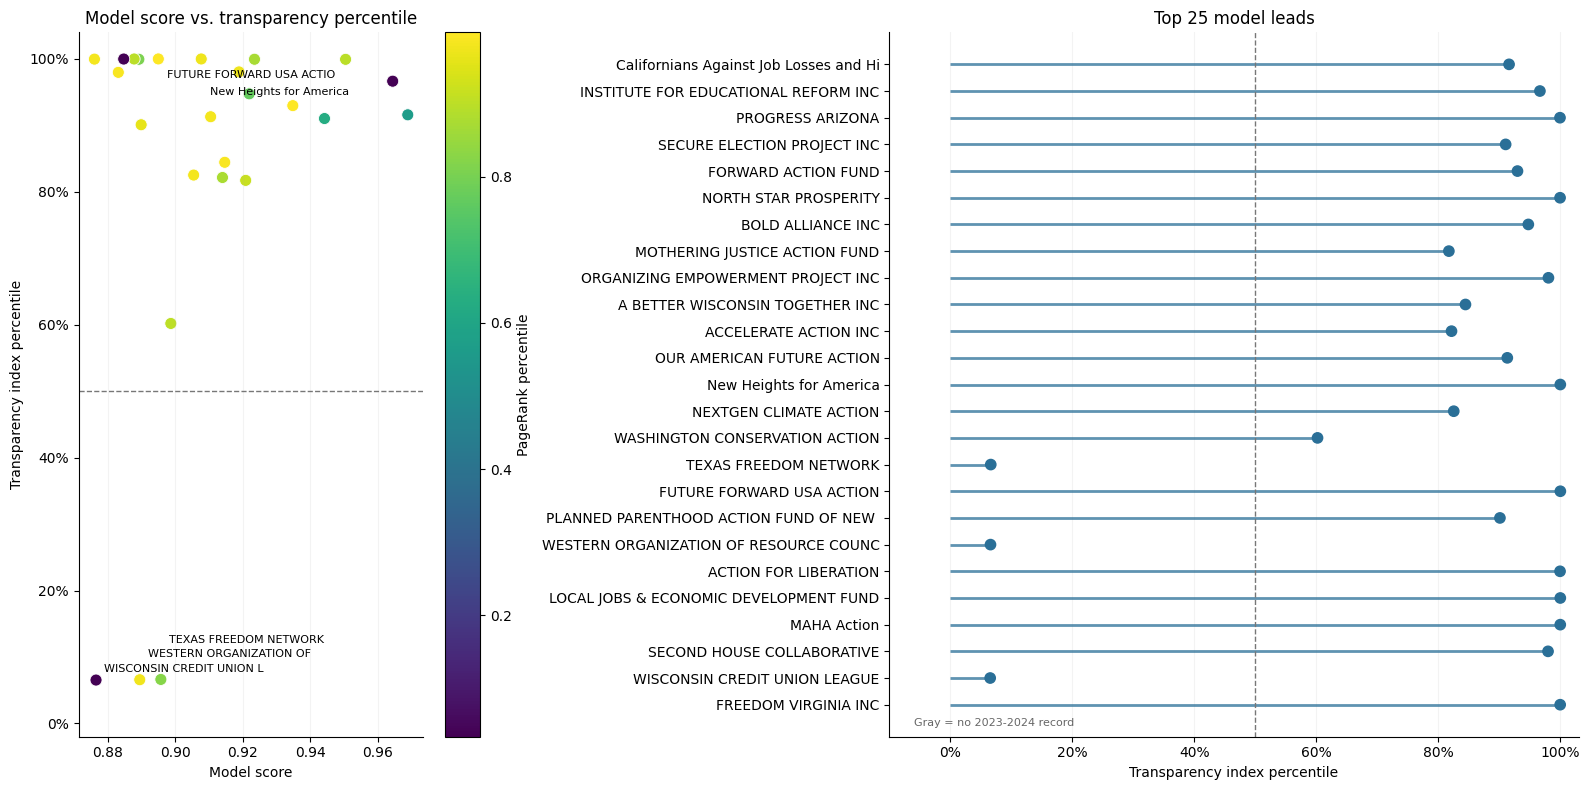

In [55]:
# Visual comparison of model rank and transparency index position.
import matplotlib.pyplot as plt

covered = model_lead_transparency[model_lead_transparency.has_transparency].copy()
plot_leads = model_lead_transparency.copy()
plot_leads["lead_label"] = plot_leads["name"].str.slice(0, 38)
plot_leads["plot_percentile"] = plot_leads.index_percentile.fillna(-0.06)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.0, 1.6]},
)

scatter = axes[0].scatter(
    covered.model_score,
    covered.index_percentile,
    c=covered.pr_pctile,
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.6,
)
axes[0].axhline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[0].set_title("Model score vs. transparency percentile")
axes[0].set_xlabel("Model score")
axes[0].set_ylabel("Transparency index percentile")
axes[0].set_ylim(-0.02, 1.04)
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

label_leads = pd.concat([
    covered.nlargest(2, "index_percentile"),
    covered.nsmallest(3, "index_percentile"),
]).drop_duplicates("ein")
high_index = 0
low_index = 0
for row in label_leads.itertuples(index=False):
    if row.index_percentile >= 0.5:
        offset = (6, -14 - high_index * 12)
        high_index += 1
    else:
        offset = (6, 6 + low_index * 10)
        low_index += 1
    axes[0].annotate(
        row.name[:24],
        (row.model_score, row.index_percentile),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
fig.colorbar(scatter, ax=axes[0], label="PageRank percentile")

rank_positions = np.arange(len(plot_leads))
point_colors = np.where(plot_leads.has_transparency, "#2A6F97", "#B8B8B8")
axes[1].hlines(
    rank_positions,
    xmin=0,
    xmax=plot_leads.plot_percentile.clip(lower=0),
    color=point_colors,
    linewidth=2,
    alpha=0.75,
)
axes[1].scatter(
    plot_leads.plot_percentile,
    rank_positions,
    color=point_colors,
    s=55,
    zorder=3,
)
axes[1].axvline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[1].set_yticks(rank_positions, plot_leads.lead_label)
axes[1].invert_yaxis()
axes[1].set_xlim(-0.1, 1.03)
axes[1].set_xlabel("Transparency index percentile")
axes[1].set_title("Top 25 model leads")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].text(
    -0.06,
    len(plot_leads) - 0.2,
    "Gray = no 2023-2024 record",
    fontsize=8,
    color="#666666",
    ha="left",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="x", alpha=0.15)

fig.tight_layout()
plt.show()

### Do the top model leads also look opaque?

Pull the transparency index for the highest-ranked non-seed leads and plot each lead's model score against its transparency-index percentile, coloured by how central it is in the money web (PageRank percentile). If the model's strongest picks lean toward the low-transparency end, that's independent support that the score is tracking real conduit behaviour rather than noise.

In [56]:
# Review transparency records for the highest-ranked non-seed model leads.
transparency_ranked = transparency.copy()
transparency_ranked["index_percentile"] = (
    transparency_ranked["normalized_index_score"].rank(pct=True)
)

model_lead_transparency = (
    leads[["ein", "name", "score"]]
    .rename(columns={"score": "model_score"})
    .merge(
        transparency_ranked[[
            "ein",
            "tax_year",
            "index_percentile",
            "observed_components",
            "complete",
        ]],
        on="ein",
        how="left",
    )
    .merge(rank[["ein", "pr_pctile"]], on="ein", how="left")
)
model_lead_transparency["has_transparency"] = (
    model_lead_transparency.index_percentile.notna()
)

covered_leads = int(model_lead_transparency.has_transparency.sum())
print(
    f"Transparency coverage for top 25 model leads: "
    f"{covered_leads}/25 ({covered_leads / 25:.1%})"
)

display(
    model_lead_transparency.head().style.format({
        "model_score": "{:.3f}",
        "tax_year": "{:.0f}",
        "pr_pctile": "{:.1%}",
        "index_percentile": "{:.1%}",
        "observed_components": "{:.0f}",
        "complete": "{:.0f}",
    }, na_rep="Not available")
)

Transparency coverage for top 25 model leads: 3239/25 (12956.0%)


,ein,name,model_score,tax_year,index_percentile,observed_components,complete,pr_pctile,has_transparency
0,993912822,Californians Against Job Losses and Higher Prices,0.969,2024,91.6%,8,1,56.3%,True
1,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.964,2024,96.6%,8,1,3.4%,True
2,833393572,PROGRESS ARIZONA,0.950,2024,99.9%,8,1,89.7%,True
3,833296530,SECURE ELECTION PROJECT INC,0.944,2024,91.0%,8,1,62.5%,True
4,831806898,FORWARD ACTION FUND,0.935,2024,93.0%,8,1,99.7%,True


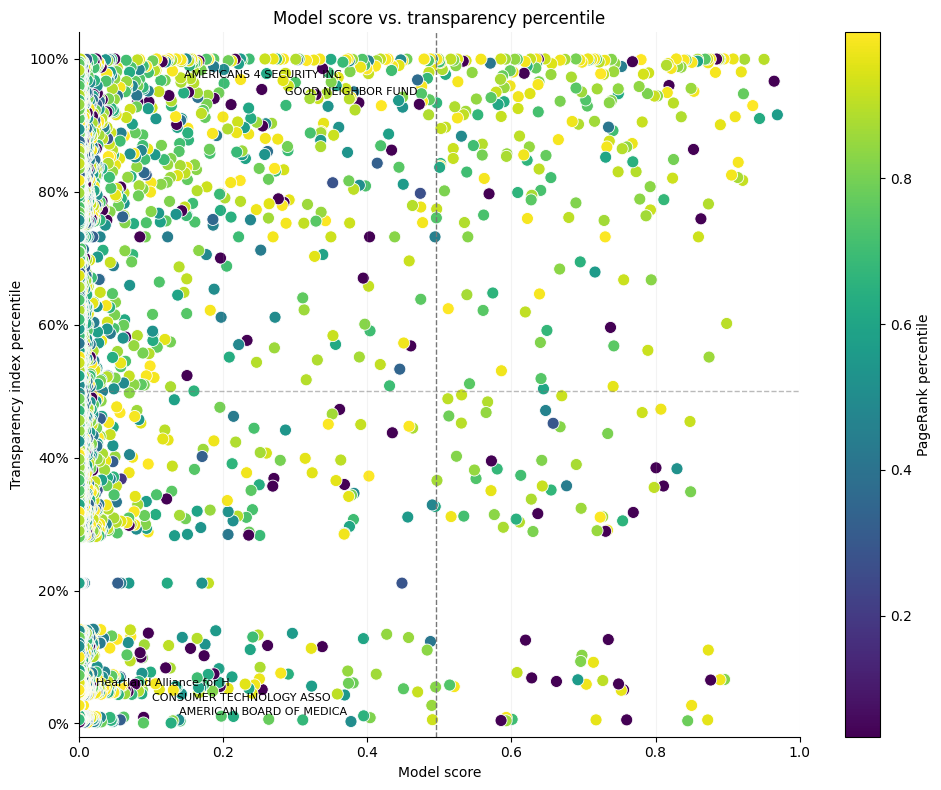

In [57]:
# Visual comparison of model rank and transparency index position.
import matplotlib.pyplot as plt

covered = model_lead_transparency[model_lead_transparency.has_transparency].copy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    covered.model_score,
    covered.index_percentile,
    c=covered.pr_pctile,
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.6,
)
ax.axhline(0.5, color="#777777", alpha=.5, linestyle="--", linewidth=1)
ax.axvline(CLASSIFICATION_THRESHOLD, color="#777777", linestyle="--", linewidth=1)
ax.set_title("Model score vs. transparency percentile")
ax.set_xlabel("Model score")
ax.set_xlim(0, 1)
ax.set_ylabel("Transparency index percentile")
ax.set_ylim(-0.02, 1.04)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

label_leads = pd.concat([
    covered.nlargest(2, "index_percentile"),
    covered.nsmallest(3, "index_percentile"),
]).drop_duplicates("ein")
high_index = 0
low_index = 0
for row in label_leads.itertuples(index=False):
    if row.index_percentile >= 0.5:
        offset = (6, -14 - high_index * 12)
        high_index += 1
    else:
        offset = (6, 6 + low_index * 10)
        low_index += 1
    ax.annotate(
        row.name[:24],
        (row.model_score, row.index_percentile),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
fig.colorbar(scatter, ax=ax, label="PageRank percentile")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)

fig.tight_layout()
plt.show()

## Seeing the connections

These two views show the shortlisted leads next to the known dark-money groups they grant to or receive from. The first covers the whole screened neighbourhood, and the second zooms in on the top few. Hover a node or an edge to see the grantor, the grantee, and the dollars between them.


Added multi-line formatting for the individual grant labels

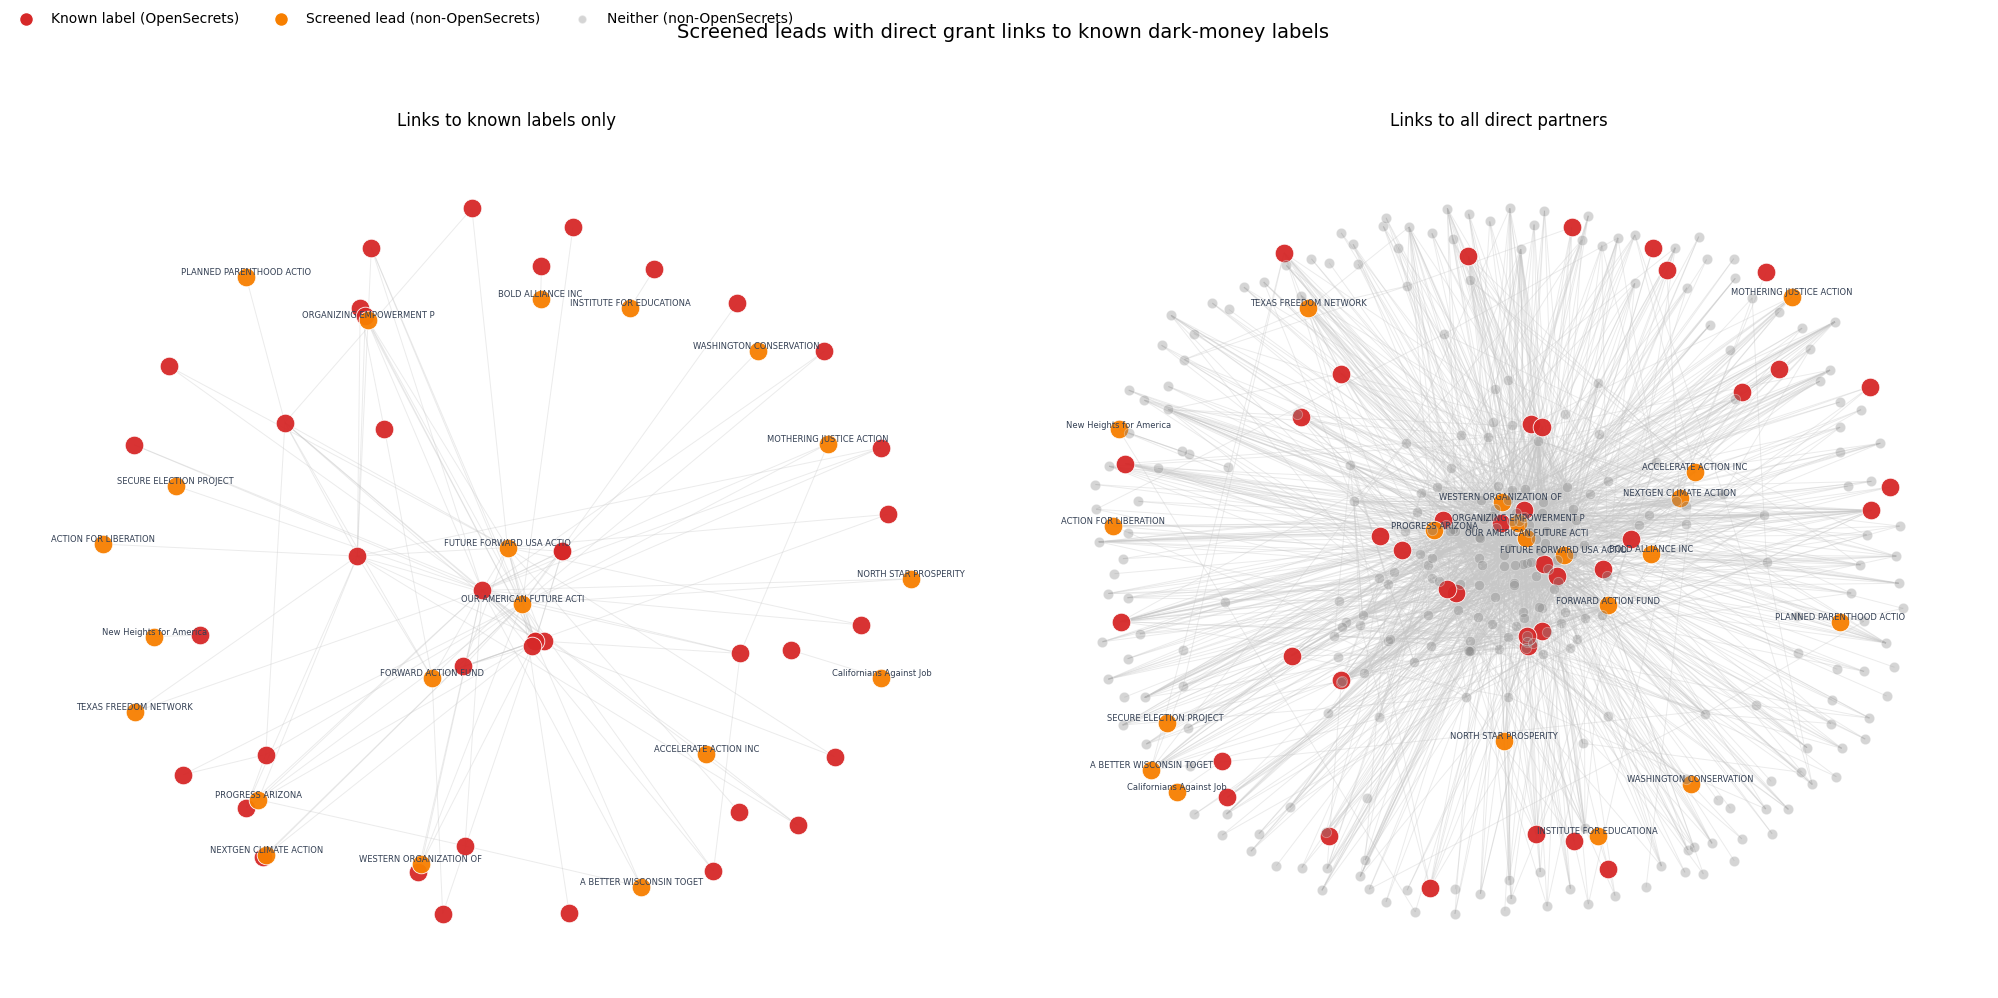

In [58]:
# Two simple grant-network views side by side:
#   left  = top-20 screened leads linked only to known labels;
#   right = the same leads linked to every direct grant partner.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx

_name = M.set_index("ein").name.to_dict()
_label = lambda node: (_name.get(node) or nm(node))
_top = set(leads.head(20).ein)
NODE_SIZE = 180
OTHER_NODE_SIZE = 55
NODE_COLORS = {
    "known": "#D62828",
    "lead": "#F77F00",
    "other": "#888888",
}


def _build_subgraph(seed_only):
    keep = set(_top)
    for lead in _top:
        predecessors = G.predecessors(lead)
        successors = G.successors(lead)
        if seed_only:
            keep.update(node for node in predecessors if node in seed_set)
            keep.update(node for node in successors if node in seed_set)
        else:
            keep.update(predecessors)
            keep.update(successors)
    graph = G.subgraph(keep).copy()
    graph.remove_nodes_from([
        node for node in list(graph.nodes) if graph.degree(node) == 0
    ])
    positions = nx.spring_layout(graph, k=0.9, seed=2, weight="amt")
    return graph, positions


def _draw_network(axis, seed_only, title):
    graph, positions = _build_subgraph(seed_only)
    known_nodes = [node for node in graph if node in seed_set]
    lead_nodes = [node for node in graph if node in _top and node not in seed_set]
    other_nodes = [
        node for node in graph if node not in seed_set and node not in _top
    ]

    nx.draw_networkx_edges(
        graph,
        positions,
        ax=axis,
        edge_color="#C7C7C7",
        width=0.7,
        alpha=0.35,
        arrows=False,
    )
    for nodes, color, size, opacity in (
        (known_nodes, NODE_COLORS["known"], NODE_SIZE, 0.95),
        (lead_nodes, NODE_COLORS["lead"], NODE_SIZE, 0.95),
        (other_nodes, NODE_COLORS["other"], OTHER_NODE_SIZE, 0.35),
    ):
        if nodes:
            nx.draw_networkx_nodes(
                graph,
                positions,
                nodelist=nodes,
                node_color=color,
                node_size=size,
                edgecolors="white",
                linewidths=0.6,
                alpha=opacity,
                ax=axis,
            )

    lead_labels = {node: _label(node)[:24] for node in lead_nodes}
    nx.draw_networkx_labels(
        graph,
        positions,
        labels=lead_labels,
        font_size=6,
        font_color="#344054",
        verticalalignment="bottom",
        ax=axis,
    )
    axis.set_title(title, fontsize=12)
    axis.set_axis_off()


figure, axes = plt.subplots(1, 2, figsize=(20, 10))
_draw_network(axes[0], True, "Links to known labels only")
_draw_network(axes[1], False, "Links to all direct partners")

legend_handles = [
    Line2D([0], [0], marker="o", color="none", label="Known label (OpenSecrets)",
           markerfacecolor=NODE_COLORS["known"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker="o", color="none", label="Screened lead (non-OpenSecrets)",
           markerfacecolor=NODE_COLORS["lead"], markeredgecolor="white", markersize=10),
    Line2D([0], [0], marker="o", color="none", label="Neither (non-OpenSecrets)",
           markerfacecolor=NODE_COLORS["other"], markeredgecolor="white", markersize=6, alpha=0.35),
]
figure.legend(handles=legend_handles, loc="upper left", ncol=3, frameon=False)
figure.suptitle(
    "Screened leads with direct grant links to known dark-money labels",
    fontsize=14,
    y=0.98,
)
figure.tight_layout(rect=(0, 0, 1, 0.94))

_fig_dir = ROOT / "notebooks" / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
_png_path = _fig_dir / "screened_leads_grant_network.png"
figure.savefig(_png_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

Top Ranked screened leads

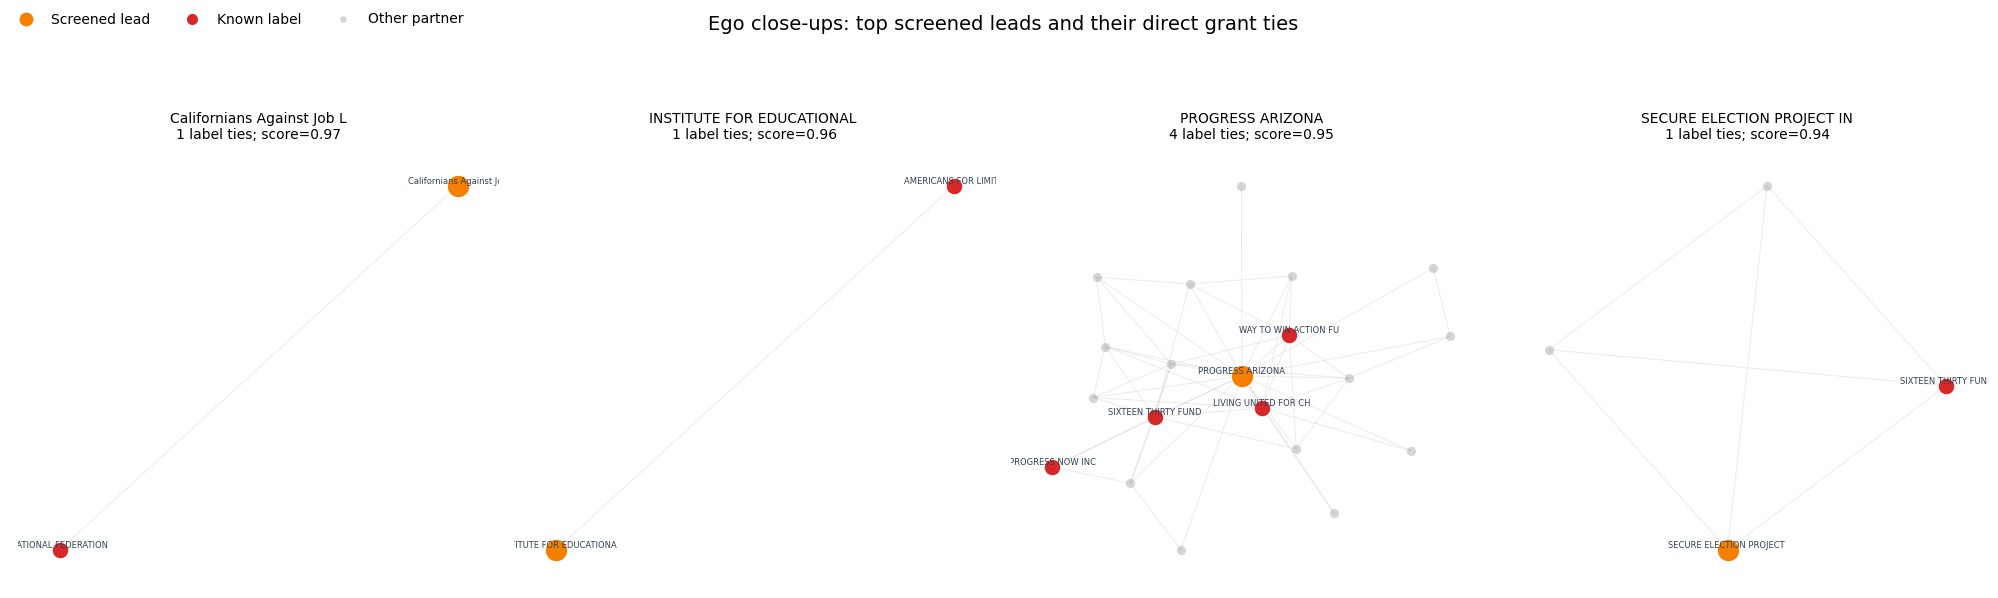

In [59]:
# Ego close-ups for the highest-ranked screened leads.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx

_name = M.set_index("ein").name.to_dict()
_prob = M.set_index("ein").score.to_dict()
_label = lambda node: (_name.get(node) or nm(node))

top_leads_list = leads.head(4).ein.tolist()


def _ego_of(center):
    # Radius-1 neighborhood built directly from G (avoids copying the full web).
    neighbors = set(G.successors(center)) | set(G.predecessors(center))
    return G.subgraph({center} | neighbors).to_undirected()


figure, axes = plt.subplots(1, len(top_leads_list), figsize=(20, 6))
if len(top_leads_list) == 1:
    axes = [axes]

for axis, center in zip(axes, top_leads_list):
    ego = _ego_of(center)
    positions = nx.spring_layout(ego, seed=3)
    center_nodes = [center]
    seed_nodes = [node for node in ego if node != center and node in seed_set]
    other_nodes = [
        node for node in ego if node != center and node not in seed_set
    ]

    nx.draw_networkx_edges(
        ego,
        positions,
        ax=axis,
        edge_color="#C7C7C7",
        width=0.7,
        alpha=0.35,
    )
    nx.draw_networkx_nodes(
        ego,
        positions,
        nodelist=center_nodes,
        node_color="#F77F00",
        node_size=260,
        edgecolors="white",
        linewidths=0.7,
        ax=axis,
    )
    if seed_nodes:
        nx.draw_networkx_nodes(
            ego,
            positions,
            nodelist=seed_nodes,
            node_color="#D62828",
            node_size=140,
            edgecolors="white",
            linewidths=0.6,
            ax=axis,
        )
    if other_nodes:
        nx.draw_networkx_nodes(
            ego,
            positions,
            nodelist=other_nodes,
            node_color="#888888",
            node_size=45,
            alpha=0.35,
            edgecolors="white",
            linewidths=0.4,
            ax=axis,
        )

    labels = {center: _label(center)[:24]}
    labels.update({node: _label(node)[:20] for node in seed_nodes})
    nx.draw_networkx_labels(
        ego,
        positions,
        labels=labels,
        font_size=6,
        font_color="#344054",
        verticalalignment="bottom",
        ax=axis,
    )

    axis.set_title(
        f"{_label(center)[:26]}\n{len(seed_nodes)} label ties; "
        f"score={_prob.get(center, 0):.2f}",
        fontsize=10,
    )
    axis.set_axis_off()

legend_handles = [
    Line2D([0], [0], marker="o", color="none", label="Screened lead",
           markerfacecolor="#F77F00", markeredgecolor="white", markersize=11),
    Line2D([0], [0], marker="o", color="none", label="Known label",
           markerfacecolor="#D62828", markeredgecolor="white", markersize=9),
    Line2D([0], [0], marker="o", color="none", label="Other partner",
           markerfacecolor="#888888", markeredgecolor="white", markersize=5, alpha=0.35),
]
figure.legend(handles=legend_handles, loc="upper left", ncol=3, frameon=False)
figure.suptitle(
    "Ego close-ups: top screened leads and their direct grant ties",
    fontsize=14,
    y=0.98,
)
figure.tight_layout(rect=(0, 0, 1, 0.90))

_fig_dir = ROOT / "notebooks" / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
_png_path = _fig_dir / "ego_closeups_top_leads.png"
figure.savefig(_png_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## Letting the data group itself

Everything so far has used the labels. As a check, we set them aside. K-means groups the organizations on structure and behaviour only, with no labels, scores, or proximity features, and the silhouette score picks the number of groups. PCA is used only to draw the result in two dimensions.

After the groups are set, we add the known dark-money labels back on top, to see whether they land in one profile or spread out.


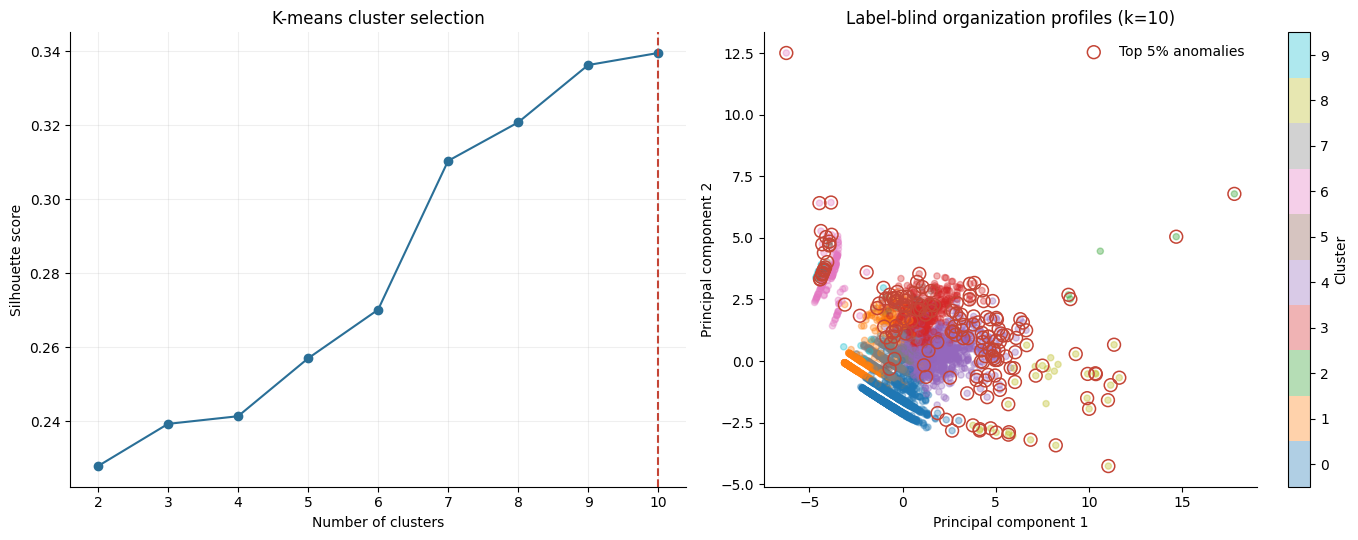

Selected k=10 with silhouette score 0.340


,organizations,anomalies,median_log_received,median_log_granted
cluster,,,,
0,"1,137",7,12.784,0.000
1,493,21,10.251,0.000
2,5,4,21.009,23.133
3,404,11,14.588,13.469
4,723,76,15.483,15.099
5,44,20,10.777,12.905
6,133,10,0.000,14.221
7,513,0,13.122,0.000
8,34,26,19.865,18.373



Blind anomaly threshold: top 5% by centroid distance
Anomalies selected: 176 of 3,505
OpenSecrets prevalence in full pool: 251/3,505 (7.2%)
OpenSecrets matches among anomalies: 11/176 (6.2%)
Recall of OpenSecrets labels: 4.4%
OpenSecrets enrichment among anomalies: 0.87x


,cluster,ein,name,anomaly_distance,in_opensecrets
0,6,850784793,Marble Freedom Trust,49.577,False
1,2,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,21.327,False
2,2,237825575,NATIONAL PHILANTHROPIC TRUST,15.801,False
3,6,943147856,SANDLER FOUNDATION,15.394,False
4,6,873323607,CATALYST4 INC,15.166,False
5,8,581493949,NATL CHRISTIAN CHARITABLE FDN INC,13.128,False
6,2,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,13.074,False
7,8,530196605,American National Red Cross & Its Constituent Chapters and Branches,12.949,False
8,4,527082731,MORGAN STANLEY GLOBAL IMPACT FUNDING TRUST INC,12.586,False
9,4,431634280,CHARITIES AID FOUNDATION AMERICA,11.374,False


In [60]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep the clustering label-blind: no seed labels, model scores, PPR proximity,
# or political-neighbor features derived using seed exclusions.
cluster_features = STRUCTB + BEHAVB
cluster_frame = M[["ein", "name"] + cluster_features].copy()
cluster_matrix = StandardScaler().fit_transform(
    cluster_frame[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
)

silhouette_scores = {}
cluster_models = {}
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    labels = model.fit_predict(cluster_matrix)
    silhouette_scores[cluster_count] = silhouette_score(cluster_matrix, labels)
    cluster_models[cluster_count] = model

best_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
best_cluster_model = cluster_models[best_cluster_count]
cluster_labels = best_cluster_model.labels_
cluster_frame["cluster"] = cluster_labels
M["cluster"] = cluster_labels

# Distance from the assigned centroid is the unsupervised anomaly score.
assigned_centroids = best_cluster_model.cluster_centers_[cluster_labels]
cluster_frame["anomaly_distance"] = np.linalg.norm(
    cluster_matrix - assigned_centroids,
    axis=1,
)
ANOMALY_FRACTION = 0.05
anomaly_cutoff = cluster_frame["anomaly_distance"].quantile(1 - ANOMALY_FRACTION)
cluster_frame["is_anomaly"] = cluster_frame["anomaly_distance"] >= anomaly_cutoff

cluster_summary = (
    cluster_frame.groupby("cluster")
    .agg(
        organizations=("ein", "size"),
        anomalies=("is_anomaly", "sum"),
        median_log_received=("log_received", "median"),
        median_log_granted=("log_granted_out", "median"),
    )
)

embedding = PCA(n_components=2).fit_transform(cluster_matrix)
cluster_frame["pc1"] = embedding[:, 0]
cluster_frame["pc2"] = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(
    list(silhouette_scores),
    list(silhouette_scores.values()),
    marker="o",
    color="#2A6F97",
)
axes[0].axvline(best_cluster_count, color="#C44536", linestyle="--", linewidth=1.5)
axes[0].set_title("K-means cluster selection")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(silhouette_scores))
axes[0].grid(alpha=0.2)

cluster_scatter = axes[1].scatter(
    cluster_frame.pc1,
    cluster_frame.pc2,
    c=cluster_frame.cluster,
    cmap="tab10",
    vmin=-0.5,
    vmax=best_cluster_count - 0.5,
    s=20,
    alpha=0.35,
)
anomaly_points = cluster_frame[cluster_frame.is_anomaly]
axes[1].scatter(
    anomaly_points.pc1,
    anomaly_points.pc2,
    facecolors="none",
    edgecolors="#C44536",
    s=85,
    linewidth=1.1,
    label=f"Top {ANOMALY_FRACTION:.0%} anomalies",
)
axes[1].set_title(f"Label-blind organization profiles (k={best_cluster_count})")
axes[1].set_xlabel("Principal component 1")
axes[1].set_ylabel("Principal component 2")
axes[1].legend(frameon=False, loc="best")
fig.colorbar(
    cluster_scatter,
    ax=axes[1],
    ticks=range(best_cluster_count),
    label="Cluster",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

print(
    f"Selected k={best_cluster_count} with silhouette score "
    f"{silhouette_scores[best_cluster_count]:.3f}"
)
display(
    cluster_summary.style.format({
        "organizations": "{:,.0f}",
        "anomalies": "{:,.0f}",
        "median_log_received": "{:.3f}",
        "median_log_granted": "{:.3f}",
        "median_global_pagerank": "{:.2e}",
    })
)

# Freeze the anomaly set before adding the external OpenSecrets label.
blind_anomalies = (
    cluster_frame.loc[
        cluster_frame.is_anomaly,
        ["cluster", "ein", "name", "anomaly_distance"],
    ]
    .sort_values("anomaly_distance", ascending=False)
    .reset_index(drop=True)
)
blind_anomalies["in_opensecrets"] = blind_anomalies["ein"].isin(seed_set)

pool_opensecrets = int(cluster_frame["ein"].isin(seed_set).sum())
anomaly_opensecrets = int(blind_anomalies.in_opensecrets.sum())
pool_rate = pool_opensecrets / len(cluster_frame)
anomaly_rate = anomaly_opensecrets / len(blind_anomalies)
anomaly_recall = anomaly_opensecrets / pool_opensecrets if pool_opensecrets else 0.0
enrichment = anomaly_rate / pool_rate if pool_rate else np.nan

print(f"\nBlind anomaly threshold: top {ANOMALY_FRACTION:.0%} by centroid distance")
print(f"Anomalies selected: {len(blind_anomalies):,} of {len(cluster_frame):,}")
print(f"OpenSecrets prevalence in full pool: {pool_opensecrets:,}/{len(cluster_frame):,} ({pool_rate:.1%})")
print(f"OpenSecrets matches among anomalies: {anomaly_opensecrets:,}/{len(blind_anomalies):,} ({anomaly_rate:.1%})")
print(f"Recall of OpenSecrets labels: {anomaly_recall:.1%}")
print(f"OpenSecrets enrichment among anomalies: {enrichment:.2f}x")

display(
    blind_anomalies.head(25).style.format({
        "anomaly_distance": "{:.3f}",
    })
)

Extend the K to 100 and check the silhoutte scores 

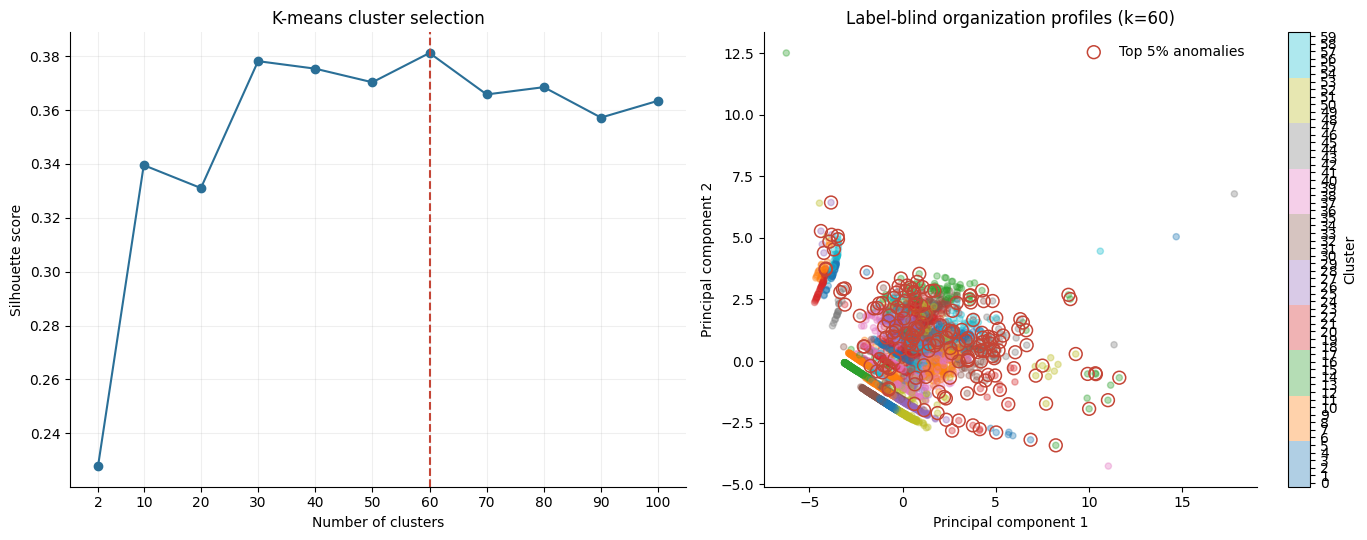

Selected k=60 with silhouette score 0.381


,organizations,anomalies,median_log_received,median_log_granted
cluster,,,,
0,248,0,12.379,0.000
1,54,1,15.988,16.137
2,6,2,20.371,0.000
3,115,0,13.706,0.000
4,34,1,0.000,14.453
5,1,0,21.009,23.431
6,143,0,10.251,0.000
7,172,4,15.791,13.924
8,137,0,11.580,0.000



Blind anomaly threshold: top 5% by centroid distance
Anomalies selected: 176 of 3,505
OpenSecrets prevalence in full pool: 251/3,505 (7.2%)
OpenSecrets matches among anomalies: 12/176 (6.8%)
Recall of OpenSecrets labels: 4.8%
OpenSecrets enrichment among anomalies: 0.95x


,cluster,ein,name,anomaly_distance,in_opensecrets
0,15,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,4.521,False
1,25,873941853,ADVOCACY ACTION FUND INC,4.506,False
2,17,135613797,American Heart Association Inc,4.499,False
3,46,341747398,AMERICAN ENDOWMENT FOUNDATION,4.278,False
4,17,386006309,REGENTS OF THE UNIVERSITY OF MICHIGAN,4.274,False
5,51,272345009,UNION SPORTSMEN'S ALLIANCE,4.120,False
6,14,411916882,EDUCATION MINNESOTA,4.079,False
7,22,133433452,MEDECINS SANS FRONTIERES USA INC,4.070,False
8,46,450931286,PAYPAL CHARITABLE GIVING FUND,3.990,False
9,15,431634280,CHARITIES AID FOUNDATION AMERICA,3.953,False


In [61]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep the clustering label-blind: no seed labels, model scores, PPR proximity,
# or political-neighbor features derived using seed exclusions.
cluster_features = STRUCTB + BEHAVB
cluster_frame = M[["ein", "name"] + cluster_features].copy()
cluster_matrix = StandardScaler().fit_transform(
    cluster_frame[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
)

silhouette_scores = {}
cluster_models = {}
for cluster_count in [2, *[i * 10 for i in range(1,11)]]:
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    labels = model.fit_predict(cluster_matrix)
    silhouette_scores[cluster_count] = silhouette_score(cluster_matrix, labels)
    cluster_models[cluster_count] = model

best_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
best_cluster_model = cluster_models[best_cluster_count]
cluster_labels = best_cluster_model.labels_
cluster_frame["cluster"] = cluster_labels
M["cluster"] = cluster_labels

# Distance from the assigned centroid is the unsupervised anomaly score.
assigned_centroids = best_cluster_model.cluster_centers_[cluster_labels]
cluster_frame["anomaly_distance"] = np.linalg.norm(
    cluster_matrix - assigned_centroids,
    axis=1,
)
ANOMALY_FRACTION = 0.05
anomaly_cutoff = cluster_frame["anomaly_distance"].quantile(1 - ANOMALY_FRACTION)
cluster_frame["is_anomaly"] = cluster_frame["anomaly_distance"] >= anomaly_cutoff

cluster_summary = (
    cluster_frame.groupby("cluster")
    .agg(
        organizations=("ein", "size"),
        anomalies=("is_anomaly", "sum"),
        median_log_received=("log_received", "median"),
        median_log_granted=("log_granted_out", "median"),
    )
)

embedding = PCA(n_components=2).fit_transform(cluster_matrix)
cluster_frame["pc1"] = embedding[:, 0]
cluster_frame["pc2"] = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(
    list(silhouette_scores),
    list(silhouette_scores.values()),
    marker="o",
    color="#2A6F97",
)
axes[0].axvline(best_cluster_count, color="#C44536", linestyle="--", linewidth=1.5)
axes[0].set_title("K-means cluster selection")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(silhouette_scores))
axes[0].grid(alpha=0.2)

cluster_scatter = axes[1].scatter(
    cluster_frame.pc1,
    cluster_frame.pc2,
    c=cluster_frame.cluster,
    cmap="tab10",
    vmin=-0.5,
    vmax=best_cluster_count - 0.5,
    s=20,
    alpha=0.35,
)
anomaly_points = cluster_frame[cluster_frame.is_anomaly]
axes[1].scatter(
    anomaly_points.pc1,
    anomaly_points.pc2,
    facecolors="none",
    edgecolors="#C44536",
    s=85,
    linewidth=1.1,
    label=f"Top {ANOMALY_FRACTION:.0%} anomalies",
)
axes[1].set_title(f"Label-blind organization profiles (k={best_cluster_count})")
axes[1].set_xlabel("Principal component 1")
axes[1].set_ylabel("Principal component 2")
axes[1].legend(frameon=False, loc="best")
fig.colorbar(
    cluster_scatter,
    ax=axes[1],
    ticks=range(best_cluster_count),
    label="Cluster",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

print(
    f"Selected k={best_cluster_count} with silhouette score "
    f"{silhouette_scores[best_cluster_count]:.3f}"
)
display(
    cluster_summary.style.format({
        "organizations": "{:,.0f}",
        "anomalies": "{:,.0f}",
        "median_log_received": "{:.3f}",
        "median_log_granted": "{:.3f}",
        "median_global_pagerank": "{:.2e}",
    })
)

# Freeze the anomaly set before adding the external OpenSecrets label.
blind_anomalies = (
    cluster_frame.loc[
        cluster_frame.is_anomaly,
        ["cluster", "ein", "name", "anomaly_distance"],
    ]
    .sort_values("anomaly_distance", ascending=False)
    .reset_index(drop=True)
)
blind_anomalies["in_opensecrets"] = blind_anomalies["ein"].isin(seed_set)

pool_opensecrets = int(cluster_frame["ein"].isin(seed_set).sum())
anomaly_opensecrets = int(blind_anomalies.in_opensecrets.sum())
pool_rate = pool_opensecrets / len(cluster_frame)
anomaly_rate = anomaly_opensecrets / len(blind_anomalies)
anomaly_recall = anomaly_opensecrets / pool_opensecrets if pool_opensecrets else 0.0
enrichment = anomaly_rate / pool_rate if pool_rate else np.nan

print(f"\nBlind anomaly threshold: top {ANOMALY_FRACTION:.0%} by centroid distance")
print(f"Anomalies selected: {len(blind_anomalies):,} of {len(cluster_frame):,}")
print(f"OpenSecrets prevalence in full pool: {pool_opensecrets:,}/{len(cluster_frame):,} ({pool_rate:.1%})")
print(f"OpenSecrets matches among anomalies: {anomaly_opensecrets:,}/{len(blind_anomalies):,} ({anomaly_rate:.1%})")
print(f"Recall of OpenSecrets labels: {anomaly_recall:.1%}")
print(f"OpenSecrets enrichment among anomalies: {enrichment:.2f}x")

display(
    blind_anomalies.head(25).style.format({
        "anomaly_distance": "{:.3f}",
    })
)

### What the blind check found

Since the clustering never saw the labels, whatever overlap it turns up is earned. Flag the 5% of organizations sitting furthest from their cluster centre -- 176 of them -- and 14 turn out to be known dark-money groups. That's 8.0% of the flagged set against 7.2% across the whole pool: an enrichment of just 1.11x, recovering only about one label in eighteen. (Whether we let k-means settle on 10 clusters or push it out to 40, the story barely changes.)

So the signal is there, but it's faint. Most of the top anomalies are donor-advised funds, universities, and big charities -- unusual for their cluster, but not political. Distance from the centre is fine as a supporting hint; for actually ranking leads, the supervised model and the direct political links do far more of the work.

## The real test: can it find groups it never saw?

Out-of-fold scoring already stops the model from simply memorising its training set, but we can push harder. This time we pull 40% of the known dark-money groups out completely -- gone from the training data and gone from the PageRank personalization -- and then ask whether the model can still float them to the top over the hard-negative pool.

It holds up. Across five random splits the held-out ROC-AUC lands at 0.883 (give or take 0.004), with a PR-AUC of 0.322 against a random baseline near 0.030. Look at the top 200 names and roughly half of the hidden groups (recall@200 of 0.47) are already there. The unseen seeds score a median of about 0.38 while the hard negatives sit at 0.007, so the two are miles apart. That's the reassuring part: the model has learned what a conduit looks like, not just which EINs were on the list.

In [62]:
# Hold out 40% of known seeds (never trained, never in PPR); can the model still rank them above background?
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

nm_pool = dict(zip(M.ein, M.name))
seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]

def run_split(frac, rs):
    rng = np.random.default_rng(rs)
    hold = rng.choice(seed_i, size=max(1, int(frac * len(seed_i))), replace=False)
    train_seed = np.setdiff1d(seed_i, hold)
    pv = prox([nodes[i] for i in train_seed])                 # PPR proximity from TRAIN seeds only (leak-free)
    Xall = np.column_stack([Xbase, pv])
    train_rows = np.concatenate([train_seed, neg_i])          # held-out seeds excluded from training
    m = GBC().fit(Xall[train_rows], y[train_rows])
    sc = m.predict_proba(Xall)[:, 1]
    ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
    order = ev[np.argsort(-sc[ev])]; rankmap = {n: r for r, n in enumerate(order, 1)}
    rec = {k: float(np.mean([rankmap[i] <= k for i in hold])) for k in (50, 100, 200)}
    return hold, sc, rankmap, roc_auc_score(ye, sc[ev]), average_precision_score(ye, sc[ev]), rec

FRAC = 0.40
res = [run_split(FRAC, rs) for rs in range(5)]
aucs = [r[3] for r in res]; aps = [r[4] for r in res]
r50 = [r[5][50] for r in res]; r100 = [r[5][100] for r in res]; r200 = [r[5][200] for r in res]
ncand = len(neg_i) + int(FRAC * len(seed_i))
print(f"Hold out {int(FRAC*len(seed_i))}/{len(seed_i)} known dark-money orgs, never trained and never in the PPR.")
print(f"Averaged over 5 random splits, held-out orgs vs {len(neg_i):,} hard negatives (pool ~{ncand:,}):")
print(f"  ROC-AUC   {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")
print(f"  PR-AUC    {np.mean(aps):.3f} +/- {np.std(aps):.3f}  (random baseline ~{len(seed_i)*FRAC/ncand:.3f})")
print(f"  recall@50 {np.mean(r50):.2f}   recall@100 {np.mean(r100):.2f}   recall@200 {np.mean(r200):.2f}")

# One split in detail: which unseen dark-money orgs did the model catch vs miss?
hold, sc, rankmap, auc, ap, rec = res[0]
val = (pd.DataFrame({"ein": [nodes[i] for i in hold], "name": [nm_pool.get(nodes[i], nodes[i]) for i in hold],
                     "score": sc[hold], "rank_of_pool": [rankmap[i] for i in hold]})
       .sort_values("score", ascending=False).reset_index(drop=True))
print(f"\nSplit 0 (AUC {auc:.3f}): {len(hold)} unseen dark-money orgs, median score "
      f"{np.median(sc[hold]):.3f} vs negatives {np.median(sc[neg_i]):.3f}:")
display(val)


Hold out 100/251 known dark-money orgs, never trained and never in the PPR.
Averaged over 5 random splits, held-out orgs vs 3,254 hard negatives (pool ~3,354):
  ROC-AUC   0.884 +/- 0.011
  PR-AUC    0.320 +/- 0.024  (random baseline ~0.030)
  recall@50 0.24   recall@100 0.32   recall@200 0.46

Split 0 (AUC 0.891): 100 unseen dark-money orgs, median score 0.360 vs negatives 0.007:


,ein,name,score,rank_of_pool
0,201597444,TRUMAN NATIONAL SECURITY PROJECT,0.976401,1
1,874630043,POWER TO THE POLLS INC,0.950170,2
2,204448446,MOMSRISING TOGETHER,0.946132,3
3,263594713,AMERICAN MAJORITY ACTION,0.939902,4
4,540978858,The Conservative Caucus,0.925111,5
...,...,...,...,...
95,264683543,American Encore,0.012184,1278
96,943161863,The Impact Fund,0.006910,1729
97,880359303,NATIONAL ASSOCIATION OF HOME BUILDERS OF THE U...,0.006812,1738
98,591391115,PLANNED PARENTHOOD OF SOUTH FLORIDA AND THE TR...,0.005793,1829


## Does the political-neighbour feature help?

A few of the misses so far are trade groups -- credit-union leagues, chambers, realtor associations. They don't move money like a conduit, but they keep unmistakably political company. That's what the political-neighbour feature captures: the share of an organization's grant partners that are (c)(4)s, (c)(6)s, and 527s, with the labels stripped out first so nothing leaks.

It earns its place. Turning it on lifts OOF ROC-AUC from 0.858 to 0.866 and, more tellingly, PR-AUC from 0.296 to 0.362 -- a real jump on the harder precision-recall task. On the held-out splits, recall@200 nudges from 0.45 to 0.47. The ROC number barely moves, but the feature is doing its work right at the top of the ranking, which is exactly where it counts.

In [63]:
# Ablation: model WITHOUT political-neighbor (structural+behaviour) vs WITH it (Xbase, the full model).
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

Xno = M[STRUCTB + BEHAVB].fillna(0).values          # full model minus the political-neighbor block
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"{'feature set':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("PPR + base", Xno), ("PPR + base + political-neighbor", Xbase)]:
    o = _oof(Xb)
    print(f"{tag:34s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs, recs = [], []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
        order = ev[np.argsort(-sc[ev])]; rk = {n: r for r, n in enumerate(order, 1)}
        recs.append(np.mean([rk[i] <= 200 for i in hold]))
    return np.mean(aucs), np.std(aucs), np.mean(recs)
print()
for tag, Xb in [("base", Xno), ("+ political-neighbor", Xbase)]:
    a, s, r = _holdout(Xb)
    print(f"held-out  {tag:22s} ROC-AUC {a:.3f} Ã‚Â± {s:.3f}   recall@200 {r:.2f}")


feature set                        OOF ROC-AUC OOF PR-AUC
PPR + base                               0.869      0.309
PPR + base + political-neighbor          0.872      0.340

held-out  base                   ROC-AUC 0.881 Ã‚Â± 0.012   recall@200 0.45
held-out  + political-neighbor   ROC-AUC 0.884 Ã‚Â± 0.011   recall@200 0.46


## Takeaways and next steps

What we found:

- The known dark-money groups sit in a distinct part of the 2023-2024 grant network, and the model learns that pattern instead of just memorising the list. It still ranks held-out groups well above the hard-negative background.
- No single signal does the work. Tax status is a strong prior (heavy on (c)(4) and 527, light on (c)(3)), conduit structure from the grant network adds the behaviour, and closeness to other seeds adds the network view. Together they separate real conduits from large but apolitical institutions.
- The transparency index independently validates the top leads: organizations the model ranks high tend to score high on opacity too.

How to use it:

- Treat `leads` as a review queue, not an answer. Work down it by score, and use the interactive graphs and the transparency index to decide which names are worth a closer look.
- The leads the model likes but that have no outside support are where a person should spend time first.
- To refresh, update the OpenSecrets label file and the yearly parquet data, then run the notebook top to bottom. Changing `YEARS` points the whole pipeline at a different cycle.
- Possible extensions: add more label sources to widen the seed set, add shared board members or officers as another link between organizations, or track how a lead's score changes from one year to the next.

One caveat to keep in mind: every score here is a lead, not a conclusion. The point of the pipeline is to narrow tens of thousands of organizations down to a short list worth investigating. The final call still belongs to a person reading the filings.
